# EASY - Environmental Awareness by the Sea and beYond

<div class="report-section"><h2>1. Executive Summary</h2></div>

<div class="report-box">
  <table>
    <tr><td><strong>Goal</strong></td><td>Build a reproducible maritime awareness pipeline for <code>boat</code>, <code>ship</code>, <code>buoy</code>, and later <code>debris</code> and <code>person</code>, across RGB imagery and future multimodal sensors.</td></tr>
    <tr><td><strong>Current Phase</strong></td><td><strong>Dataset engineering and trustworthy baseline evaluation</strong>.</td></tr>
    <tr><td><strong>Current Status</strong></td><td>The taxonomy is frozen, the data pipeline is implemented, multiple RGB baselines have been audited, and pseudo-sequence-aware evaluation is now in place.</td></tr>
    <tr><td><strong>Key Findings</strong></td><td><code>ship</code> is currently the strongest class, <code>boat</code> is usable but sensitive to split design, and <code>buoy</code> remains the main bottleneck because of scarcity, small-object difficulty, and semantic overlap with <code>boat</code>.</td></tr>
    <tr><td><strong>Next Milestone</strong></td><td>Improve <code>buoy</code> recognition through data refinement, coverage expansion, and evidence-driven small-object experiments.</td></tr>
  </table>
</div>

<div class="callout-insight"><strong>Key Insight.</strong> The project already has a trustworthy baseline and a reliable audit methodology. The main open problem is no longer “does YOLO work at all?” but “why does <code>buoy</code> fail under realistic validation conditions?”</div>

### Current status
- The taxonomy is frozen and the data pipeline is implemented.
- Official datasets have been selected, staged, converted, and exported into derived EASY datasets.
- Multiple RGB baselines have been trained and audited.
- Leakage was discovered in the original split and corrected through pseudo-sequence-aware auditing.
- <code>ship</code> is currently the strongest class.
- <code>boat</code> is usable but still sensitive to split design.
- <code>buoy</code> remains the main bottleneck.

### Key achievements
- Established a reproducible dataset-first workflow.
- Built leakage-aware <code>clean</code>, <code>balanced-v1</code>, and <code>balanced-v2</code> splits.
- Identified that the <code>buoy</code> problem is primarily a data coverage and semantic ambiguity problem, not only a model problem.
- Produced detailed <code>boat</code> vs <code>buoy</code> forensic analysis showing that many buoy instances are localized but classified as <code>boat</code>.

### Current limitations
- Only five buoy-bearing pseudo-sequences exist in the RGB dataset.
- Buoy diversity is insufficient for robust held-out generalization.
- <code>boat</code> and <code>buoy</code> have a fragile semantic boundary under the current data regime.
- The project is not yet ready to claim a fully stable operational RGB benchmark.

<div class="muted">This notebook is a research progress report rather than an experiment log. It is designed to be understandable by a university professor, a research supervisor, a project stakeholder, and a new team member joining the project.</div>


<div class="report-section"><h2>2. Project Evolution Timeline</h2></div>

The project has evolved through a sequence of increasingly rigorous phases. This timeline shows that the current baseline is the result of a structured research journey rather than a single training run.

- <strong>Phase 1</strong> - Dataset collection and harmonization  
  Official maritime datasets were selected, mapped to the EASY taxonomy, and converted into a unified working format.
- <strong>Phase 2</strong> - Dataset audit and leakage detection  
  Early high metrics triggered a deeper audit, which revealed that pseudo-sequence leakage was inflating the apparent performance.
- <strong>Phase 3</strong> - Creation of reliable train / validation / test splits  
  Leakage-aware <code>clean</code>, <code>balanced-v1</code>, and <code>balanced-v2</code> splits were created to make evaluation more realistic and scientifically defensible.
- <strong>Phase 4</strong> - Baseline YOLO training and evaluation  
  Multiple <code>YOLOv8n</code> baselines were trained to establish a lightweight, deployment-aware reference detector.
- <strong>Phase 5</strong> - Error analysis and bottleneck identification  
  Confusion analysis and qualitative inspection showed that <code>buoy</code> is not simply missed, but often confused with <code>boat</code>, especially in small-object regimes.
- <strong>Phase 6</strong> - Current research assessment and planning  
  The project now has a trustworthy baseline, a reliable audit methodology, and a clear understanding of the main bottlenecks.
- <strong>Phase 7</strong> - Next research step  
  The next phase is to improve <code>buoy</code> recognition through data refinement, coverage expansion, and small-object-focused experimentation.

<div class="callout-observation"><strong>Important Observation.</strong> The most important transition in the timeline was the move from optimistic raw metrics to leakage-aware evaluation. That step changed the project from “promising” to scientifically trustworthy.</div>


<div class="report-section"><h2>3. Project Workflow</h2></div>

The current EASY workflow can be understood as a compact pipeline from raw maritime data to evidence-driven next steps.

```mermaid
flowchart TD
    A[Raw Maritime Datasets] --> B[Dataset Harmonization]
    B --> C[Leakage Audit]
    C --> D[Reliable Data Splits]
    D --> E[YOLO Training]
    E --> F[Evaluation]
    F --> G[Error Analysis]
    G --> H[Future Improvements]
```

### Stage interpretation
- <strong>Raw Maritime Datasets.</strong> The project starts from heterogeneous official sources with different modalities, annotation conventions, and strengths.
- <strong>Dataset Harmonization.</strong> These sources are staged, mapped, and converted into a common EASY-compatible format.
- <strong>Leakage Audit.</strong> Pseudo-sequence relationships are inspected to prevent train/validation/test contamination.
- <strong>Reliable Data Splits.</strong> Clean and balanced splits are built to support trustworthy comparison.
- <strong>YOLO Training.</strong> Lightweight pretrained baselines are trained as a fast and deployment-aware reference.
- <strong>Evaluation.</strong> Global and per-class metrics reveal which parts of the task are genuinely solved and which are not.
- <strong>Error Analysis.</strong> Confusion matrices and qualitative overlays identify semantic and small-object failure modes.
- <strong>Future Improvements.</strong> The roadmap is derived from evidence, not from model-scaling assumptions alone.

<div class="callout-insight"><strong>Key Insight.</strong> A new reader should be able to understand the project in under a minute: EASY is not just training detectors, but building a reliable maritime perception pipeline whose conclusions can be trusted.</div>


In [2]:
from pathlib import Path
from IPython.display import HTML, Image, Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
assert (ROOT / "docs").exists(), f"Could not locate repo root from {Path.cwd()}"

display(HTML("""
<style>
.report-section {
    background: linear-gradient(135deg, #0f172a 0%, #1e293b 100%);
    color: white;
    padding: 14px 18px;
    border-radius: 12px;
    margin: 18px 0 12px 0;
    box-shadow: 0 4px 14px rgba(15, 23, 42, 0.12);
}
.report-section h2 {
    margin: 0;
    font-size: 1.55rem;
}
.report-box {
    background: #f8fafc;
    border: 1px solid #dbeafe;
    border-left: 6px solid #2563eb;
    border-radius: 10px;
    padding: 14px 16px;
    margin: 12px 0;
}
.callout-insight {
    background: #ecfeff;
    border-left: 6px solid #0891b2;
    padding: 12px 14px;
    border-radius: 8px;
    margin: 12px 0;
}
.callout-observation {
    background: #eff6ff;
    border-left: 6px solid #2563eb;
    padding: 12px 14px;
    border-radius: 8px;
    margin: 12px 0;
}
.callout-warning {
    background: #fff7ed;
    border-left: 6px solid #ea580c;
    padding: 12px 14px;
    border-radius: 8px;
    margin: 12px 0;
}
.callout-future {
    background: #f0fdf4;
    border-left: 6px solid #16a34a;
    padding: 12px 14px;
    border-radius: 8px;
    margin: 12px 0;
}
.muted {
    color: #475569;
}
.tight li { margin: 4px 0; }
</style>
"""))

def repo_path(relative_path: str) -> Path:
    return ROOT / relative_path

def show_image(relative_path: str, width: int = 900):
    display(Image(filename=str(repo_path(relative_path)), width=width))

print(f"Repo root resolved to: {ROOT}")


Repo root resolved to: /home/c.coppola/projects/EASY/easy-maritime-awareness


<div class="report-section"><h2>4. Project Context</h2></div>

The EASY project addresses the broader problem of <strong>maritime environmental awareness</strong>: building a system that can perceive and reason about relevant foreground entities in realistic sea scenes.

This is important because maritime scenes are difficult in ways that are not fully captured by generic object detection benchmarks:
- small objects at long range
- cluttered water backgrounds
- glare and reflections
- waves and wake artifacts
- strong weather and illumination variability
- visual overlap between semantically different floating objects

The long-term vision is a maritime awareness system capable of detecting and monitoring:
- <code>boat</code>
- <code>ship</code>
- <code>buoy</code>
- <code>debris</code>
- <code>person</code>

using RGB imagery now, and future multimodal sensors later, including thermal and potentially stereo-based sensing.

<div class="callout-observation"><strong>Important Observation.</strong> The current RGB detector is only the first operational component of a broader maritime awareness system. Its value comes from being both measurable today and extensible toward future sensing and deployment stages.</div>

### Expected final system
```text
EASY System
├── RGB perception
│   └── boat / ship / buoy
├── Thermal companion perception
│   └── debris / person
├── Future tracking layer
│   └── object persistence over time
└── Future embedded deployment
    └── edge-ready maritime awareness
```


<div class="report-section"><h2>5. Dataset Analysis</h2></div>

The current EASY scope is built on three official datasets:
- <code>SMD</code>
- <code>SeaShips</code>
- <code>MassMIND</code>

Each was selected for a specific role, not simply for size.

<div class="report-box">
<strong>SMD</strong> is the only meaningful source of <code>buoy</code> evidence and mixed small-object maritime context.  
<strong>SeaShips</strong> strengthens vessel coverage, especially <code>ship</code>.  
<strong>MassMIND</strong> keeps the broader EASY roadmap aligned with future thermal work on <code>debris</code> and <code>person</code>.
</div>

### SMD
<code>SMD</code> is the primary RGB dataset. It is indispensable because it is the only source that currently contributes meaningful <code>buoy</code> evidence, and it also provides SMD-style <code>boat</code> scenes that are visually distinct from SeaShips.

<strong>Advantages</strong>
- only meaningful source of <code>buoy</code>
- useful <code>boat</code> context
- natural sequence structure, which is critical for leakage-aware splitting

<strong>Limitations</strong>
- limited buoy-bearing pseudo-sequences
- insufficient internal buoy diversity
- weaker <code>ship</code> support than SeaShips

### SeaShips
<code>SeaShips</code> is the support RGB dataset. It strengthens <code>ship</code> coverage and contributes many vessel scenes, including additional <code>boat</code> examples.

<strong>Advantages</strong>
- strong <code>ship</code> coverage
- large number of vessel scenes
- useful support for <code>boat</code> / <code>ship</code> discrimination

<strong>Limitations</strong>
- does not contribute <code>buoy</code>
- many pseudo-sequences are nearly monoclasse <code>ship</code>

### MassMIND
<code>MassMIND</code> is retained as a <strong>thermal companion dataset</strong>. It is important because the official EASY taxonomy includes <code>debris</code> and <code>person</code>, but it is intentionally kept separate from the main RGB baseline.

<strong>Advantages</strong>
- thermal evidence for future multimodal work
- useful for <code>debris</code> and <code>person</code>
- keeps the broader EASY taxonomy meaningful

<strong>Limitations</strong>
- not suitable for direct mixing into the first RGB baseline
- requires modality-aware interpretation and careful mapping

### Why these datasets were selected
- use <code>SMD</code> because <code>buoy</code> only exists there
- use <code>SeaShips</code> because <code>ship</code> coverage is much stronger there
- keep <code>MassMIND</code> because EASY is broader than RGB-3 and must retain <code>debris</code> / <code>person</code>

### Dataset composition

<strong>Table 1. RGB-3 split composition</strong>

| Split | Images | Labels | Labels With Objects | Empty Labels |
| --- | ---: | ---: | ---: | ---: |
| train | 4172 | 4172 | 4172 | 0 |
| val | 2430 | 2430 | 2430 | 0 |
| test | 3843 | 3843 | 3843 | 0 |

<strong>Table 2. RGB-3 class distribution</strong>

| Class | Count | Percentage |
| --- | ---: | ---: |
| <code>boat</code> | 3663 | 26.71% |
| <code>ship</code> | 7031 | 51.27% |
| <code>buoy</code> | 3021 | 22.03% |

<strong>Interpretation.</strong>  
At the aggregate class-count level, the RGB-3 dataset does not look catastrophically imbalanced. <code>ship</code> is dominant, but <code>boat</code> and <code>buoy</code> are not rare in absolute count. This is important because it shows that the main problem is <strong>not simple global class frequency</strong>.

However, class counts alone are misleading. The key issue is how those counts are distributed across pseudo-sequences and visual regimes.

<strong>Table 3. Thermal companion class distribution</strong>

| Class | Count | Percentage |
| --- | ---: | ---: |
| <code>boat</code> | 0 | 0.00% |
| <code>ship</code> | 0 | 0.00% |
| <code>buoy</code> | 0 | 0.00% |
| <code>debris</code> | 7103 | 62.15% |
| <code>person</code> | 4325 | 37.85% |

<strong>Interpretation.</strong>  
This confirms that MassMIND is not part of the active RGB detection baseline, but it is still strategically important. It supplies the thermal evidence needed to keep <code>debris</code> and <code>person</code> in the overall EASY roadmap.

<div class="callout-insight"><strong>Key Insight.</strong> The central dataset problem is not total class count. It is the narrow distribution of buoy evidence across pseudo-sequences and visual subtypes.</div>


### SMD buoy-rich scene
`outputs/dataset_analysis/rgb3/sample_annotations/train/004_smd__MVI_1474_VIS_frame_000382.jpg`

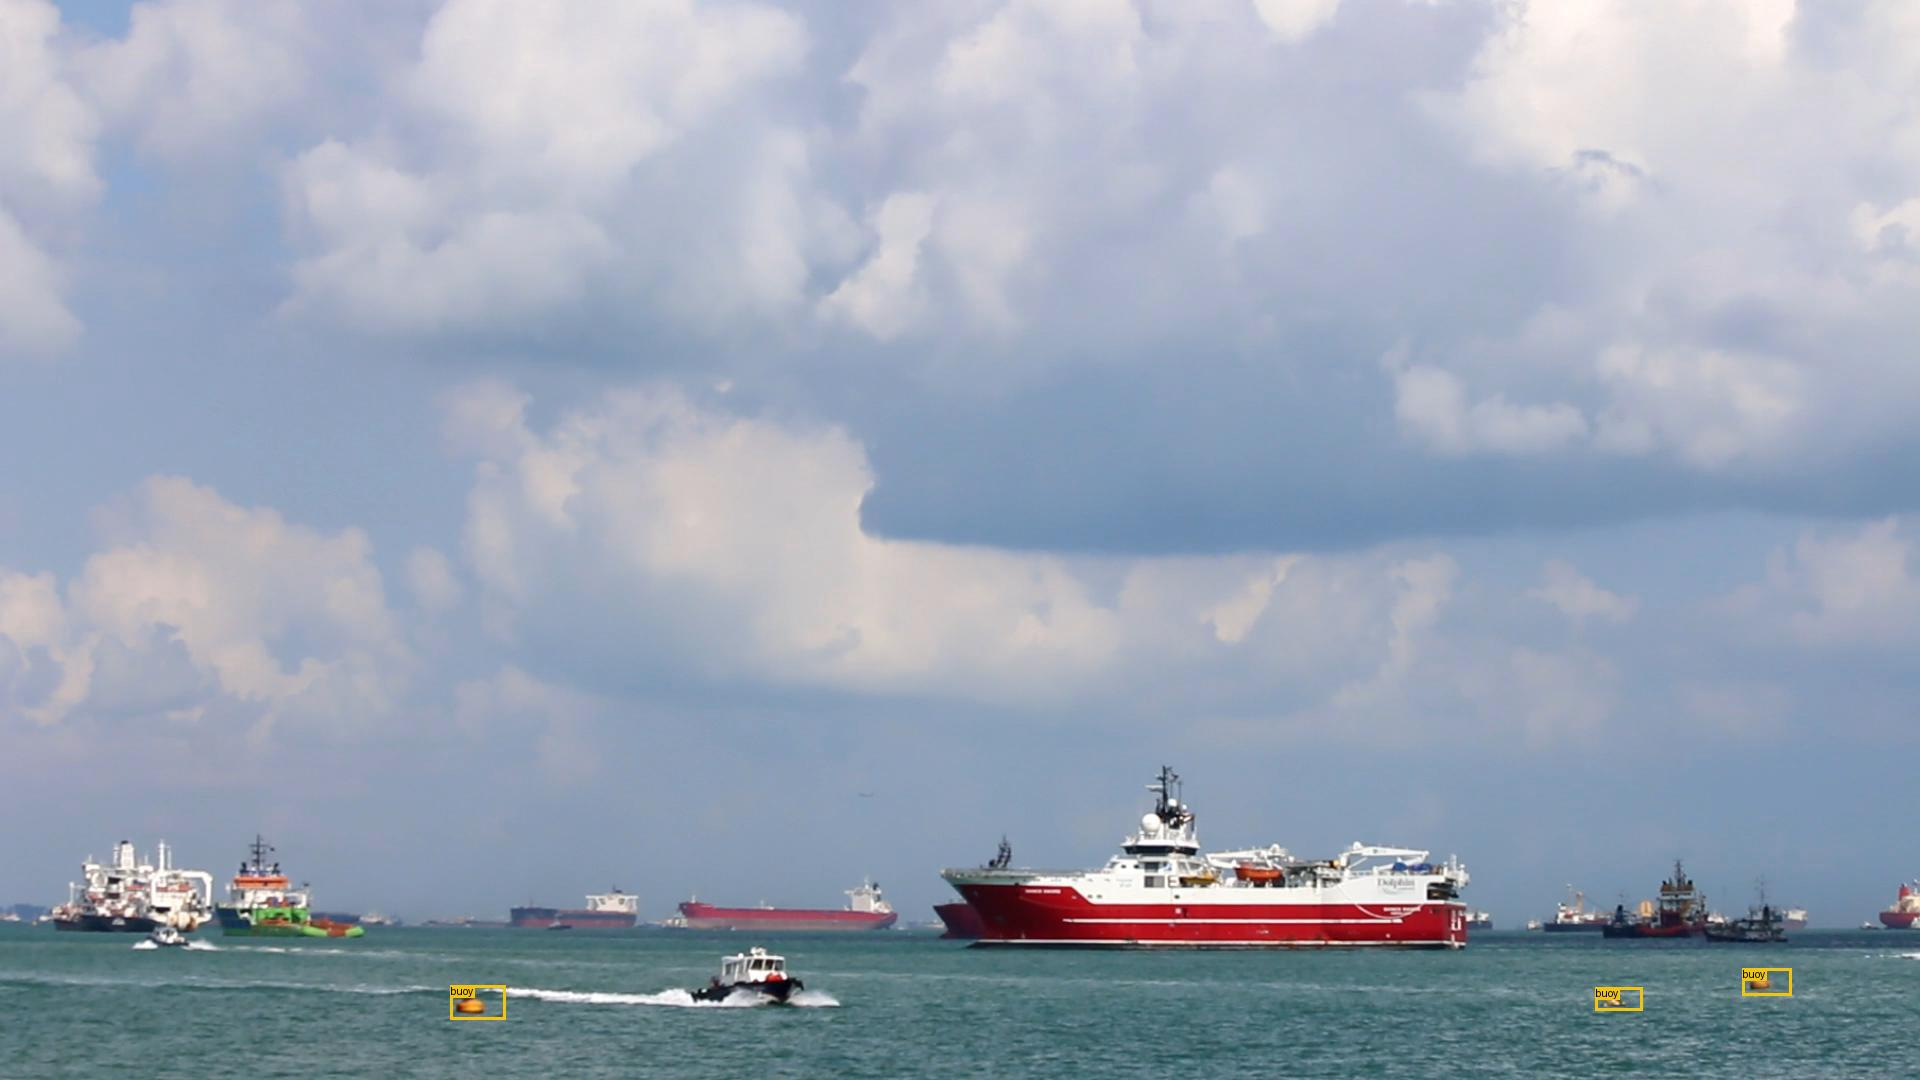

### SMD mixed boat + buoy scene
`outputs/dataset_analysis/rgb3/sample_annotations/train/005_smd__MVI_0790_VIS_OB_frame_000283.jpg`

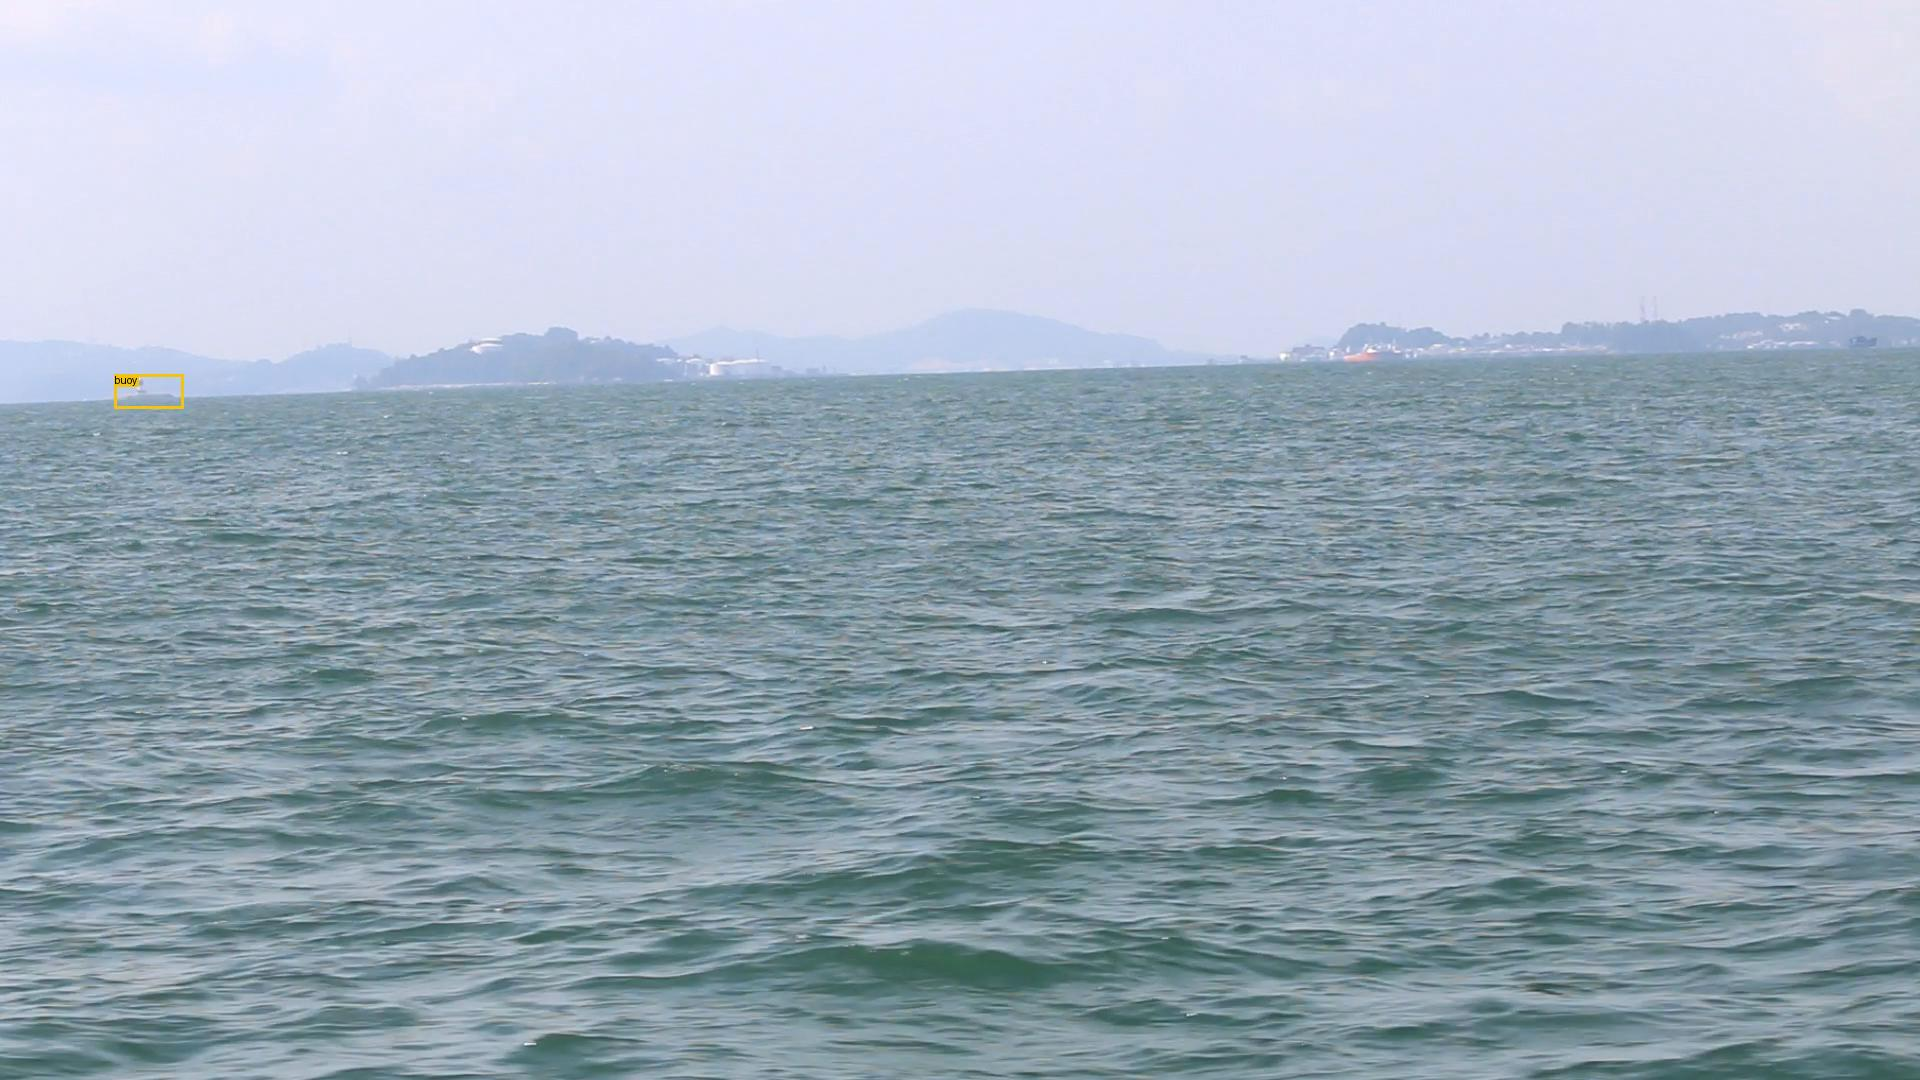

### SeaShips vessel scene
`outputs/dataset_analysis/rgb3/sample_annotations/test/003_seaships__004557.jpg`

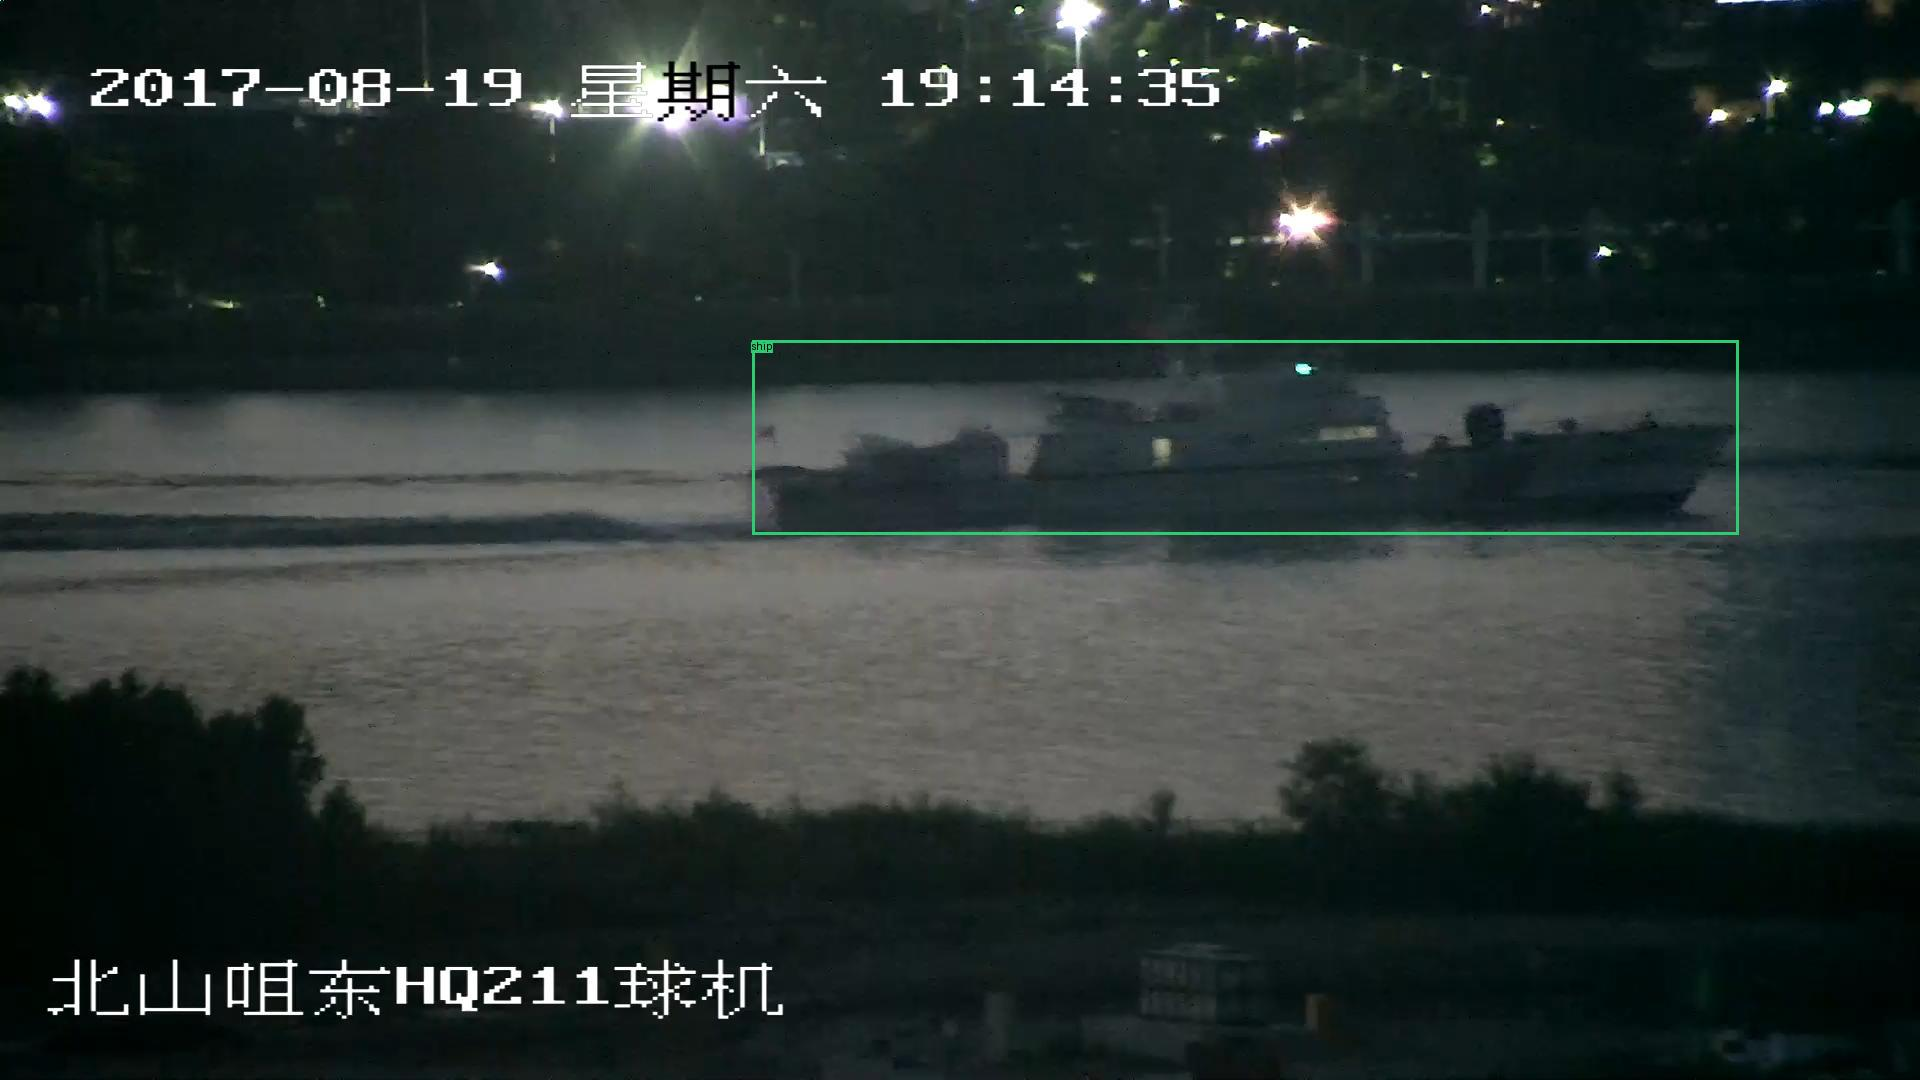

### MassMIND thermal example
`outputs/dataset_analysis/massmind_thermal/sample_annotations/train/003_b00003574.jpg`

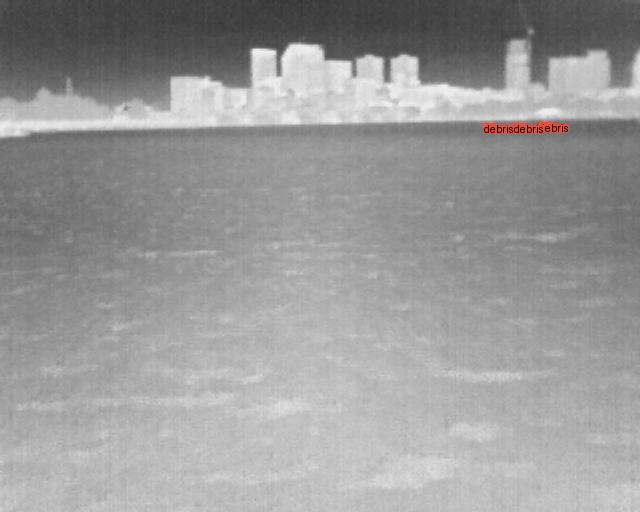

### MassMIND validation example
`outputs/dataset_analysis/massmind_thermal/sample_annotations/val/012_l00010002.jpg`

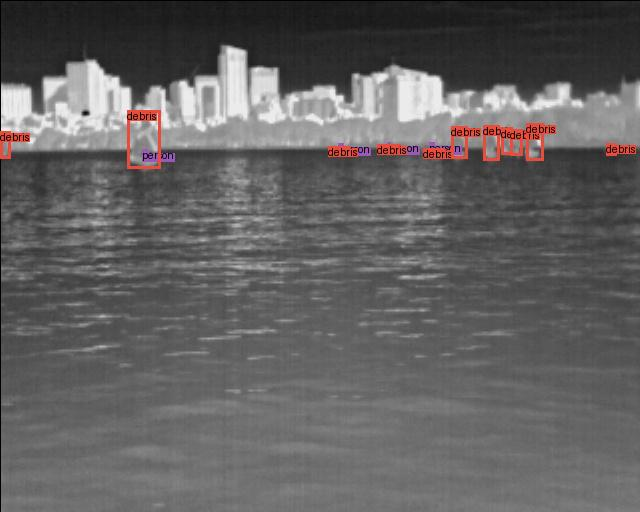

In [3]:
dataset_examples = [
    ("SMD buoy-rich scene", "outputs/dataset_analysis/rgb3/sample_annotations/train/004_smd__MVI_1474_VIS_frame_000382.jpg"),
    ("SMD mixed boat + buoy scene", "outputs/dataset_analysis/rgb3/sample_annotations/train/005_smd__MVI_0790_VIS_OB_frame_000283.jpg"),
    ("SeaShips vessel scene", "outputs/dataset_analysis/rgb3/sample_annotations/test/003_seaships__004557.jpg"),
    ("MassMIND thermal example", "outputs/dataset_analysis/massmind_thermal/sample_annotations/train/003_b00003574.jpg"),
    ("MassMIND validation example", "outputs/dataset_analysis/massmind_thermal/sample_annotations/val/012_l00010002.jpg"),
]
for title, image_path in dataset_examples:
    display(Markdown(f"### {title}\n`{image_path}`"))
    show_image(image_path, width=760)

<div class="callout-observation"><strong>Figure Interpretation.</strong> The RGB examples illustrate why SMD and SeaShips must coexist in the project: SMD contributes buoy-specific evidence and mixed context, while SeaShips contributes strong ship-heavy maritime coverage. The thermal examples show that EASY is broader than the current RGB-3 baseline and is already aligned with future multimodal perception.</div>

<div class="muted">What the reader should learn from these images: the project is solving a multi-source, multi-regime perception problem rather than a single homogeneous detection task.</div>


<div class="report-section"><h2>6. Model Selection</h2></div>

### Why YOLO was selected
YOLO was selected because the project is not only about offline accuracy; it is also about building toward a future deployable maritime awareness system.

The main reasons are:
- <strong>real-time inference potential</strong>
- <strong>lightweight architecture family</strong>
- <strong>good ecosystem support</strong>
- <strong>strong baseline for embedded deployment</strong>
- <strong>compatibility with future Raspberry Pi-oriented experiments</strong>

### Why this matters for EASY
For EASY, model choice must remain aligned with system constraints:
- future edge deployment matters
- real-time awareness is more relevant than pure benchmark chasing
- the maritime environment benefits from models that can run frequently and consistently

### Research interpretation
YOLO is therefore not presented as “the perfect final architecture”, but as a rational baseline family for:
- rapid iteration
- deployment-aware experimentation
- early-stage dataset diagnosis

<div class="callout-insight"><strong>Key Insight.</strong> The current bottleneck appears to be data quality and coverage rather than pure model expressiveness. That makes a lightweight, trustworthy baseline more valuable than an immediately larger model.</div>


<div class="report-section"><h2>7. Training Pipeline</h2></div>

The repository is built around a <strong>dataset-first training pipeline</strong>.

### Preprocessing
- official datasets are staged explicitly
- provenance is preserved
- data is converted to intermediate normalized records
- YOLO export happens only after mapping validation

<strong>Why this was done.</strong>  
This prevents silent class coercion and makes the data pipeline auditable, which is essential once split quality becomes part of the scientific result.

### Augmentation
The current baseline relies on standard YOLO augmentation behavior rather than aggressive custom augmentation.

<strong>Why this choice was made.</strong>  
At this stage the project needed a clean baseline that isolates dataset issues. Heavy augmentation would have made it harder to determine whether failures came from the model, the data, or the augmentation policy.

### Train / validation / test strategy
- SMD frames are grouped by their source video
- SeaShips images are grouped into larger pseudo-sequence blocks
- no pseudo-sequence is allowed to appear in more than one split

<strong>Why this matters.</strong>  
This is the key methodological improvement of the project. Without it, metrics can look excellent while reflecting leakage rather than true generalization.

### Training strategy
The project uses <code>YOLOv8n</code> pretrained baselines as a lightweight and deployment-aware starting point. This allows the team to:
- validate the dataset engineering stack
- obtain fast feedback
- study failure modes before scaling model size

### Evaluation metrics
- Precision
- Recall
- mAP50
- mAP50-95

<strong>Why these metrics were used.</strong>  
They provide a compact but informative view of how often predictions are correct, how often objects are missed, and how localization and class confidence interact across thresholds.

<div class="callout-observation"><strong>Important Observation.</strong> The real technical contribution of this phase is not just model training; it is the combination of controlled data preparation and leakage-aware evaluation that makes the reported numbers defensible.</div>


<div class="report-section"><h2>8. Results</h2></div>

### Quantitative Results

#### Table 4. Global baseline comparison

| Split / baseline | Precision | Recall | mAP50 | mAP50-95 | F1 |
| --- | ---: | ---: | ---: | ---: | ---: |
| <code>rgb3</code> | <strong>0.96140</strong> | <strong>0.94657</strong> | <strong>0.98036</strong> | <strong>0.77264</strong> | <strong>0.95393</strong> |
| <code>clean</code> | 0.87665 | 0.49337 | 0.51615 | 0.31597 | 0.63140 |
| <code>balanced-v1</code> | 0.58949 | 0.36423 | 0.38999 | 0.24078 | 0.45026 |
| <code>balanced-v2</code> | 0.89154 | 0.41673 | 0.43560 | 0.27231 | 0.56797 |

<strong>Interpretation.</strong>  
The original <code>rgb3</code> metrics were too optimistic because of leakage. Once leakage was reduced, performance dropped sharply, revealing the true difficulty of the task. <code>clean</code> exposed the buoy collapse, <code>balanced-v1</code> improved buoy but damaged boat, and <code>balanced-v2</code> restored a healthier train regime while remaining a hard and realistic evaluation split.

<div class="callout-warning"><strong>Warning.</strong> The best global values belong to the original <code>rgb3</code> split, but those numbers should be interpreted as an optimistic upper bound rather than as the most trustworthy baseline.</div>

#### Table 5. Current per-class result on <code>balanced-v2</code>

| Class | Precision | Recall | mAP50 | mAP50-95 | F1 |
| --- | ---: | ---: | ---: | ---: | ---: |
| <code>boat</code> | 0.76176 | 0.38017 | 0.43031 | 0.23984 | 0.50720 |
| <code>ship</code> | 0.87924 | <strong>0.83755</strong> | <strong>0.86697</strong> | <strong>0.58144</strong> | <strong>0.85789</strong> |
| <code>buoy</code> | <strong>1.00000</strong> | 0.00000 | 0.06412 | 0.02946 | 0.00000 |

<strong>Interpretation.</strong>  
<code>ship</code> is clearly the most stable and learnable class. <code>boat</code> works at a moderate level, but still shows a large miss rate. <code>buoy</code> remains the major failure case: the model can sometimes rank buoy predictions, but it does not produce operationally usable buoy recall on the held-out <code>balanced-v2</code> validation regime.

<div class="callout-insight"><strong>Key Insight.</strong> The class table makes the project status immediately visible: <code>ship</code> is strong, <code>boat</code> is usable, and <code>buoy</code> is the bottleneck.</div>

### Qualitative Results

#### Figure set A. Best detections
<code>val_batch0_pred.jpg</code> is used here as a representative easier scene where vessel detection is visually convincing.

#### Figure set B. Typical detections
<code>val_batch1_pred.jpg</code> is used as an average-performance snapshot rather than a cherry-picked best case.

#### Figure set C. Difficult detections
<code>val_batch2_pred.jpg</code> highlights the kind of scene where small-object and semantic failures become more visible.


### Best detections
`outputs/runs/rgb3_balanced_v2_baseline/yolov8n_pretrained_50ep_balanced_v2_val/val_batch0_pred.jpg`

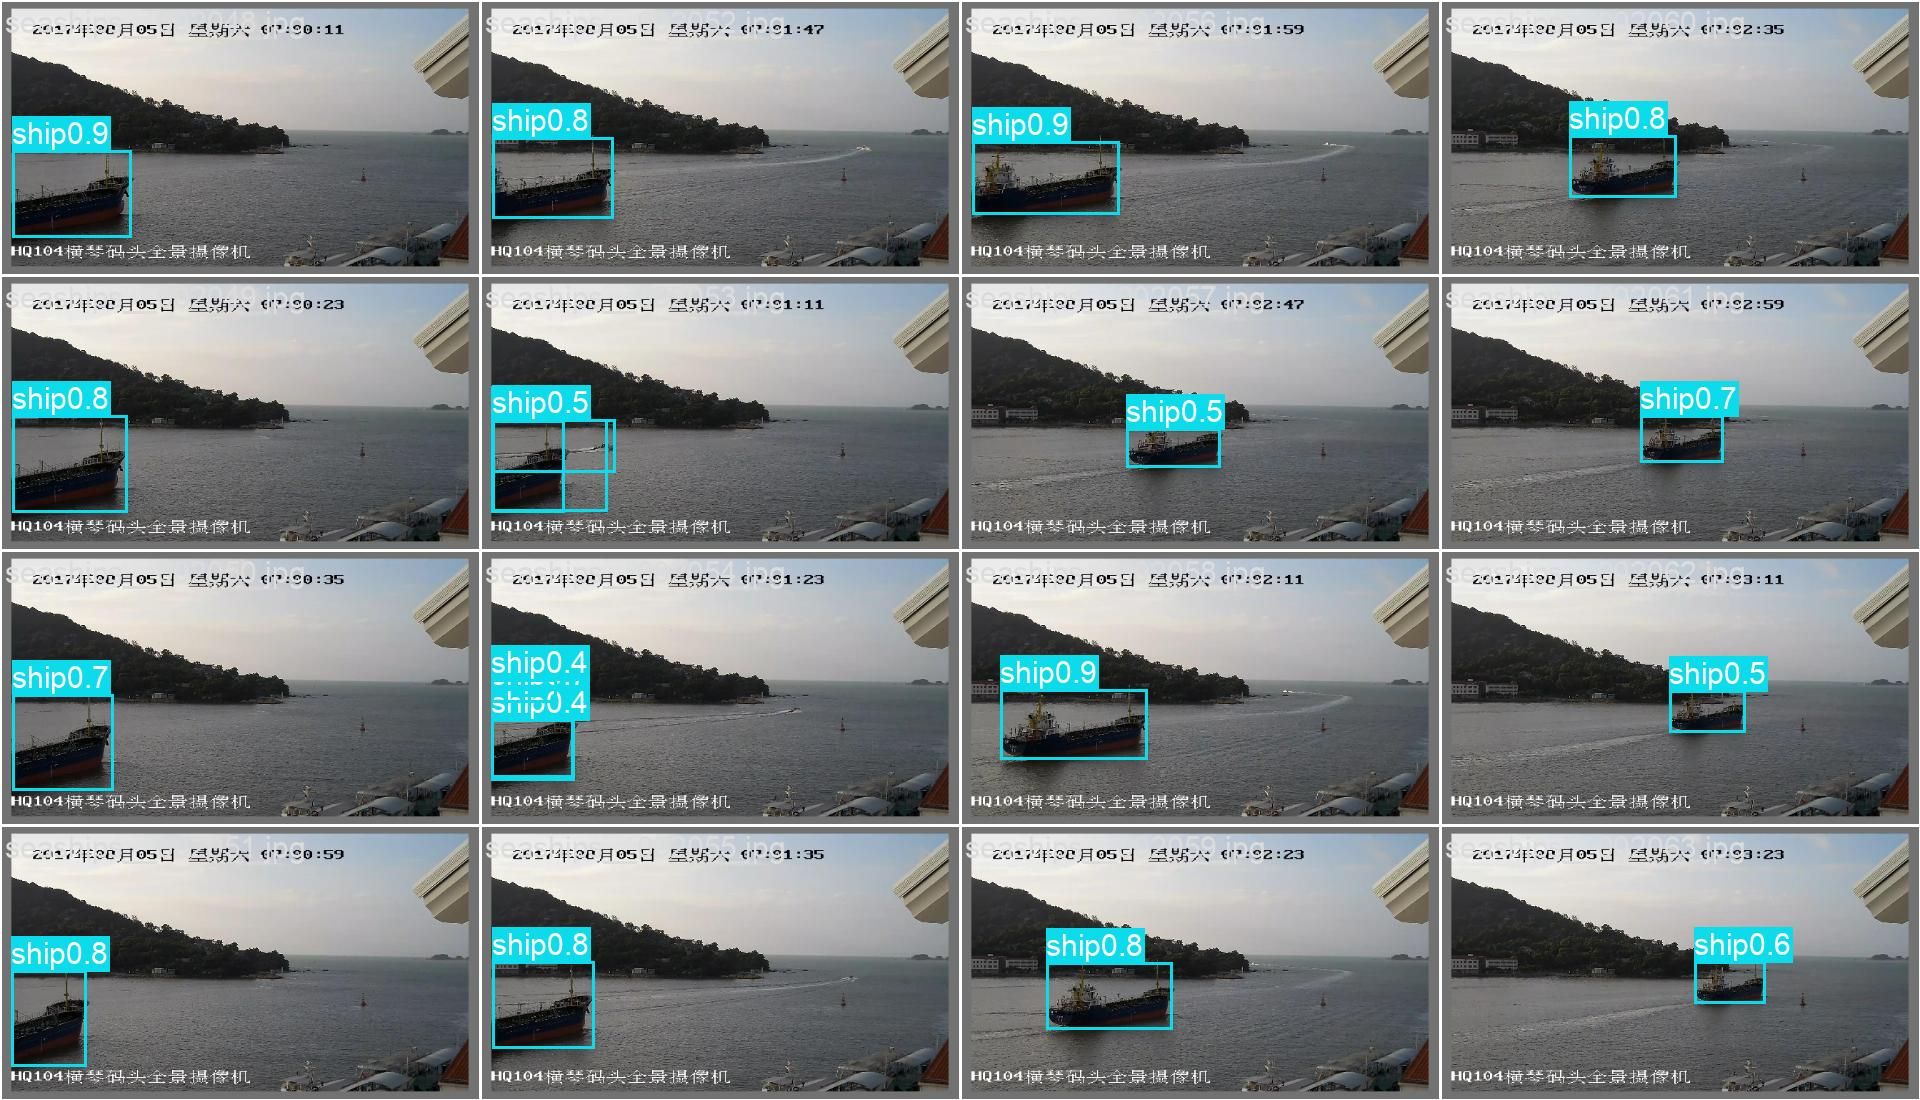

### Typical detections
`outputs/runs/rgb3_balanced_v2_baseline/yolov8n_pretrained_50ep_balanced_v2_val/val_batch1_pred.jpg`

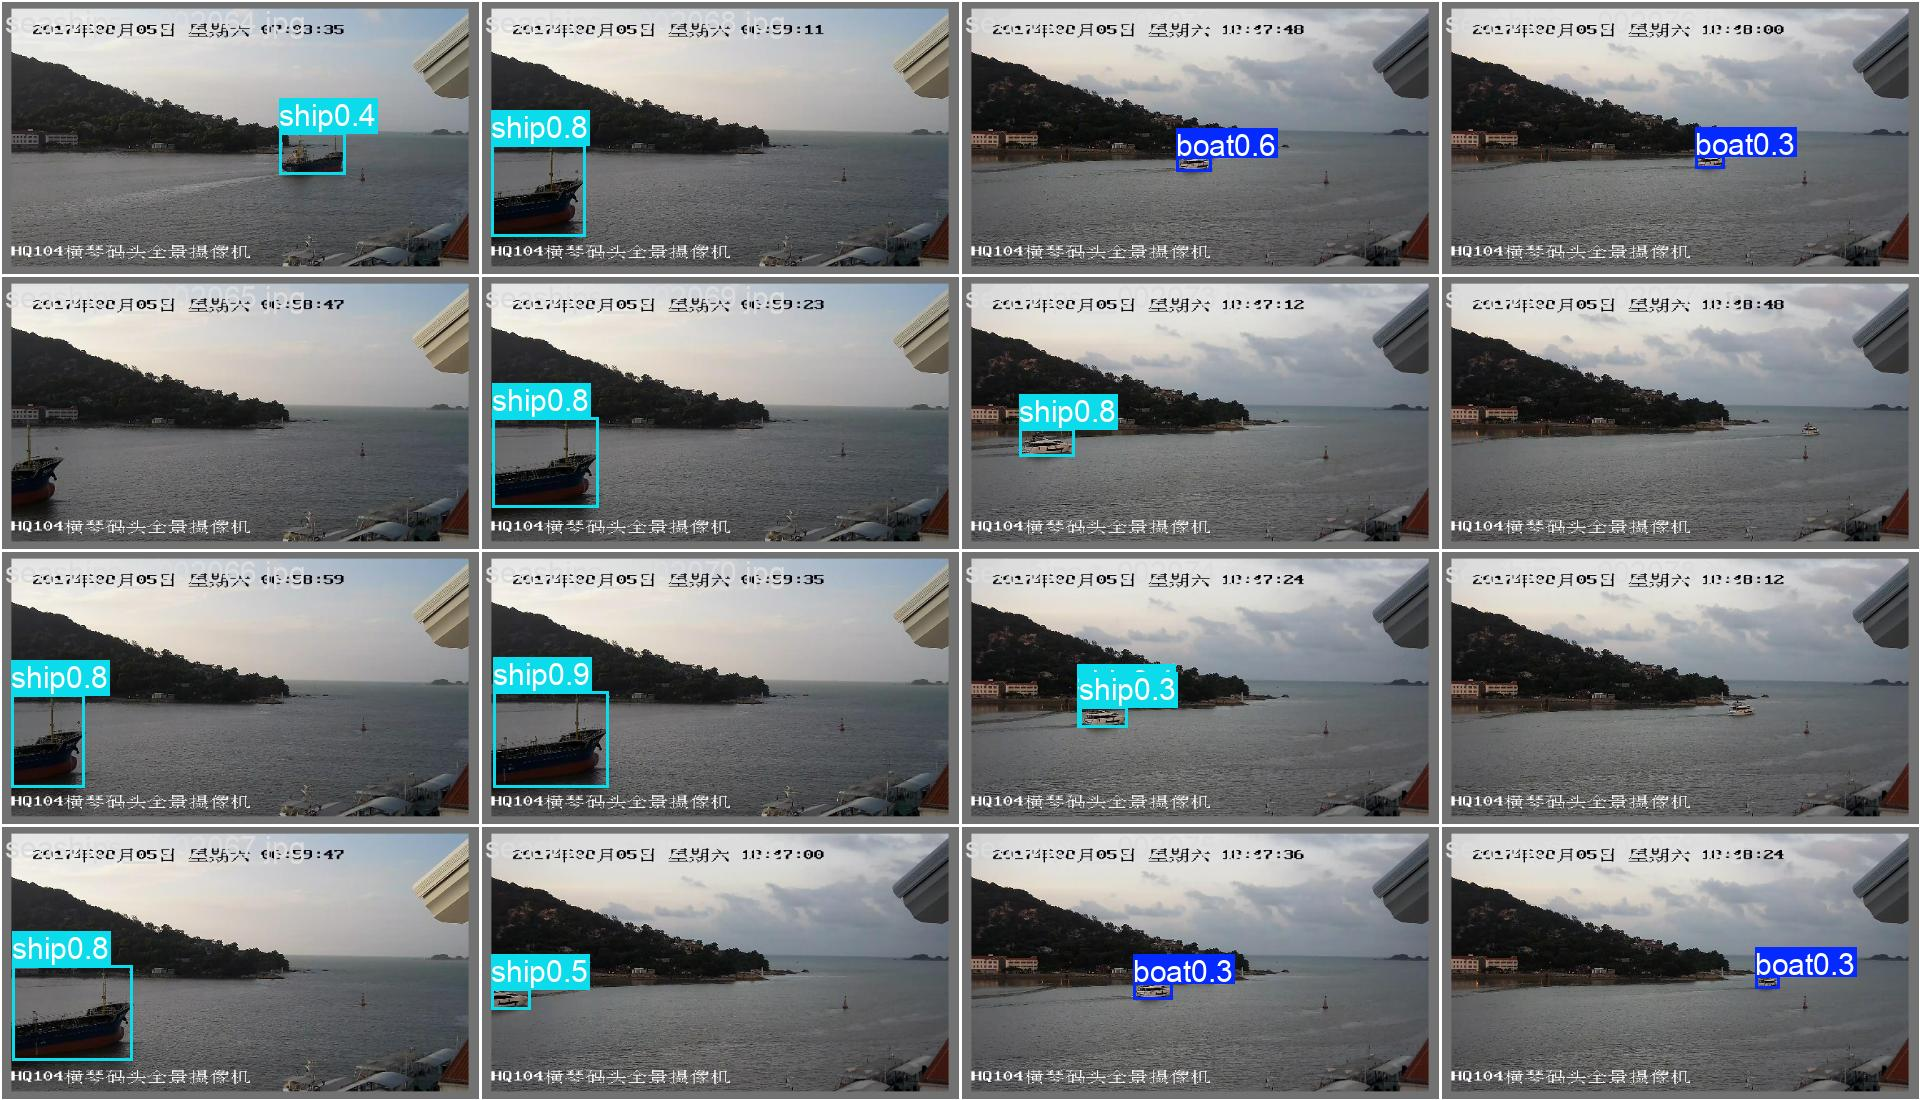

### Difficult detections
`outputs/runs/rgb3_balanced_v2_baseline/yolov8n_pretrained_50ep_balanced_v2_val/val_batch2_pred.jpg`

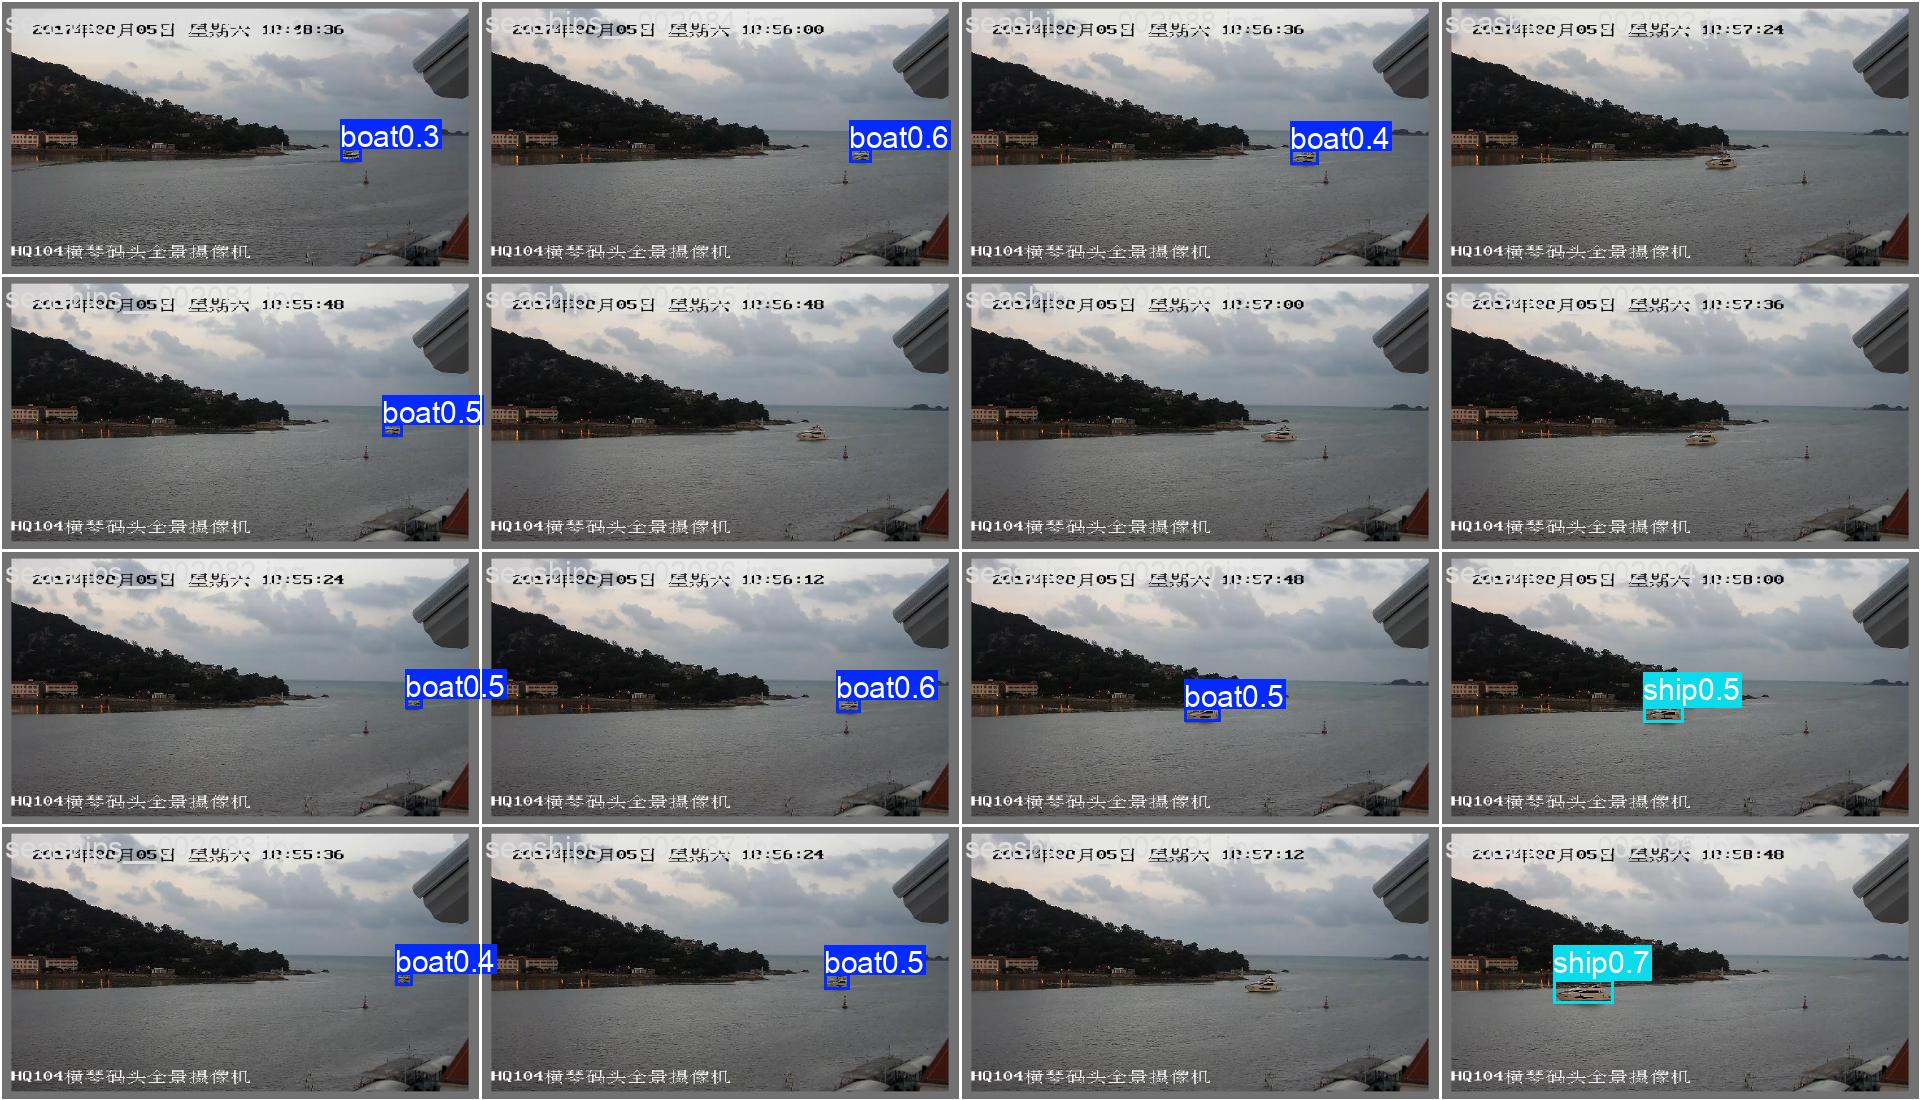

In [4]:
qualitative_results = [
    ("Best detections", "outputs/runs/rgb3_balanced_v2_baseline/yolov8n_pretrained_50ep_balanced_v2_val/val_batch0_pred.jpg"),
    ("Typical detections", "outputs/runs/rgb3_balanced_v2_baseline/yolov8n_pretrained_50ep_balanced_v2_val/val_batch1_pred.jpg"),
    ("Difficult detections", "outputs/runs/rgb3_balanced_v2_baseline/yolov8n_pretrained_50ep_balanced_v2_val/val_batch2_pred.jpg"),
]
for title, image_path in qualitative_results:
    display(Markdown(f"### {title}\n`{image_path}`"))
    show_image(image_path, width=820)

<div class="callout-observation"><strong>Figure Interpretation.</strong> These batches show that the project is not uniformly failing. Larger vessels are often detected reasonably well, which explains the stability of <code>ship</code>. The difficulty increases as object size decreases and as semantic ambiguity increases, especially near the waterline and in buoy-heavy scenes.</div>

<div class="muted">What the reader should learn from these images: the detector already handles part of the maritime task well, but its weakest regime is exactly the one dominated by small and ambiguous floating objects.</div>


<div class="report-section"><h2>9. Error Analysis</h2></div>

<div class="callout-warning"><strong>Warning.</strong> This is the most important section of the current report. The key result is not just a low buoy score, but a diagnosis of why buoy fails under realistic validation conditions.</div>

The key project result is not just a metric value, but a <strong>diagnosis</strong>:
- many buoy instances are spatially localized
- but the model often classifies them as <code>boat</code>

### Boat vs Buoy Confusion
The normalized confusion matrix below is consistent with the later forensic analysis: the main buoy failure is not random background noise, but systematic confusion with another foreground class, especially <code>boat</code>.

<div class="callout-observation"><strong>Important Observation.</strong> The confusion pattern shows that the model is often looking in the right place but assigning the wrong foreground label.</div>


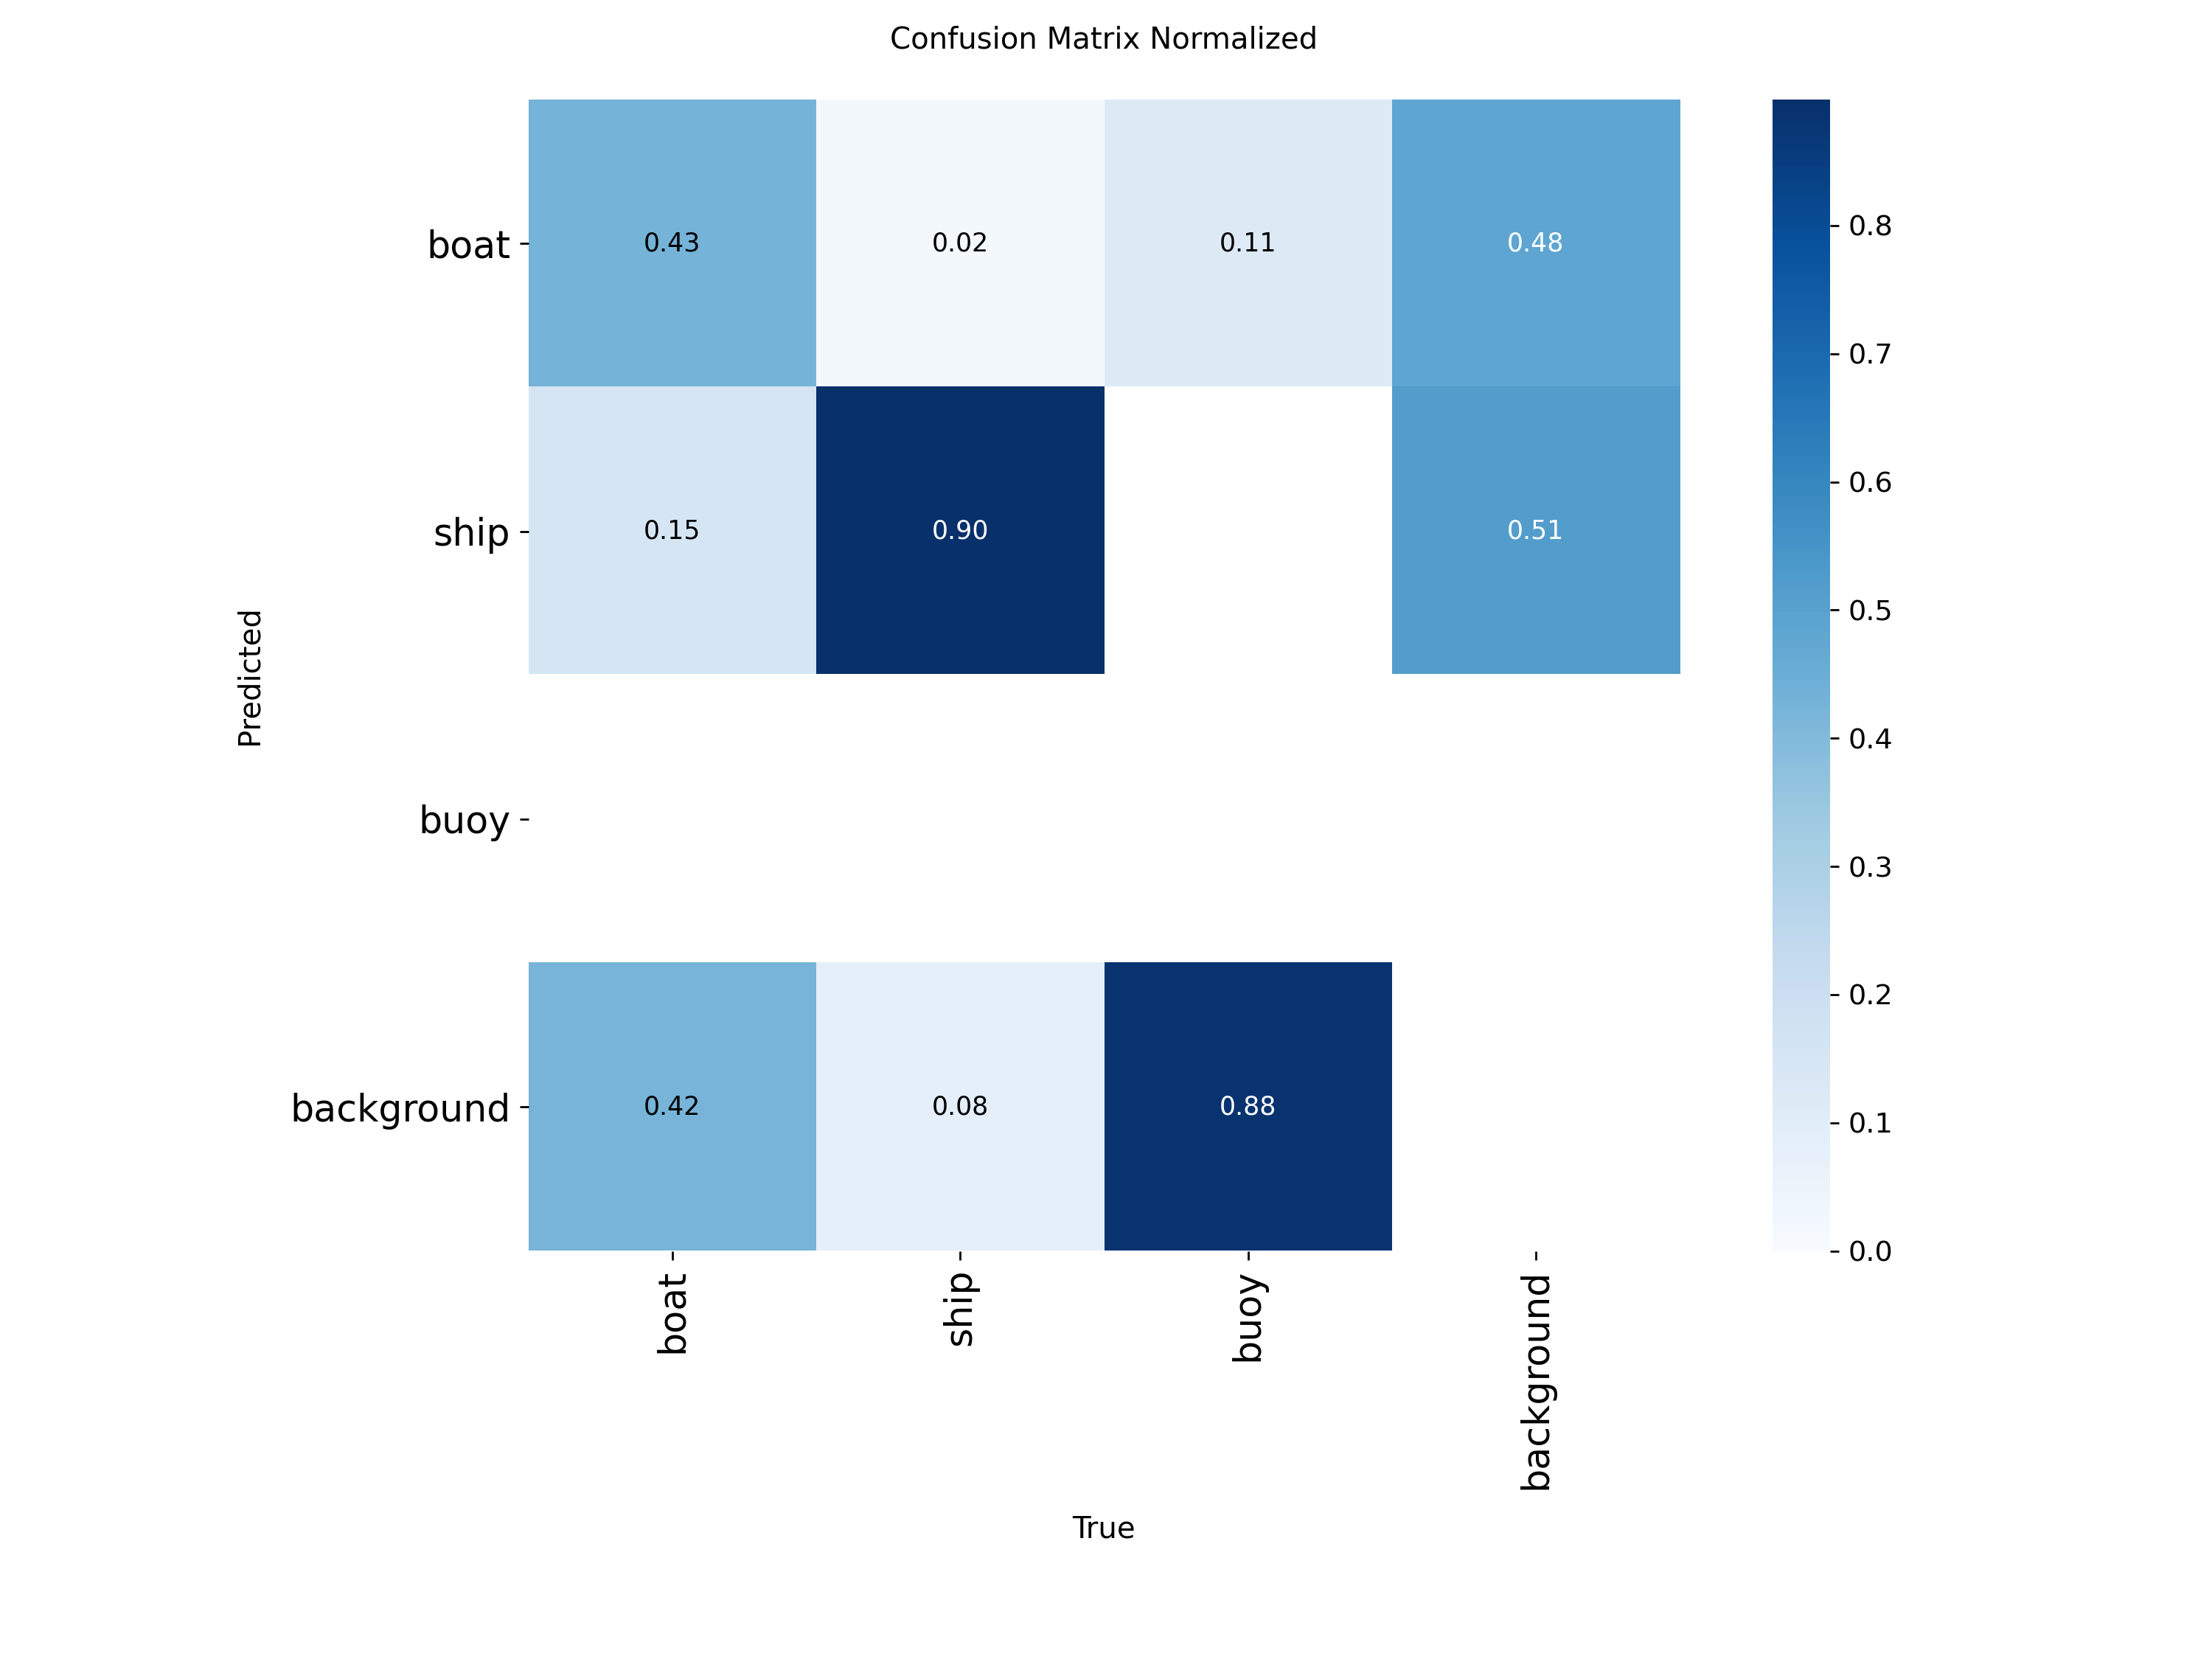

In [5]:
show_image('outputs/runs/rgb3_balanced_v2_baseline/yolov8n_pretrained_50ep_balanced_v2_val/confusion_matrix_normalized.png', width=760)

### Dedicated boat-vs-buoy forensic result

From <code>outputs/reports/boat_vs_buoy_error_analysis.md</code>:
- <code>423 / 600</code> validation buoy are matched as <code>boat</code>
- <code>93 / 600</code> are matched as low-confidence <code>buoy</code>
- <code>83 / 600</code> are missed as background
- <code>0 / 600</code> are matched as confident <code>buoy</code>

### False Positives / Wrong-Class Matches
<div class="report-box"><strong>Summary.</strong> The dominant failure mode is not pure miss detection. It is semantic confusion, where visible buoy instances are predicted as <code>boat</code>.</div>

#### False negatives
<div class="report-box"><strong>Summary.</strong> Some buoy are still missed entirely, which confirms that small-object difficulty remains part of the problem beyond semantic confusion.</div>

#### Low confidence cases
<div class="report-box"><strong>Summary.</strong> Some predictions are almost correct but not stable enough in confidence, which suggests that the model has partial buoy evidence without robust class separation.</div>

### Why does this happen?

#### Boat vs buoy confusion
- some floating objects share similar silhouettes
- some train <code>boat</code> examples occupy the same small-object regime
- the semantic boundary is fragile under current data coverage

#### False negatives
- small-object detection remains difficult
- some scenes still fall below the model’s effective confidence regime

#### Low-confidence detections
- the model sometimes “almost knows” the correct class
- the training data does not support stable buoy scoring under held-out conditions

<div class="callout-insight"><strong>Key Insight.</strong> The strongest evidence points to a combination of class scarcity in the right visual regime, pseudo-sequence scarcity, subtype shift inside <code>buoy</code>, and semantic overlap with <code>boat</code>.</div>


### GT buoy predicted as boat
`outputs/error_analysis/boat_vs_buoy/01_val_buoy_as_boat/046_smd__MVI_1469_VIS_frame_000575_cx288_cy659.jpg`

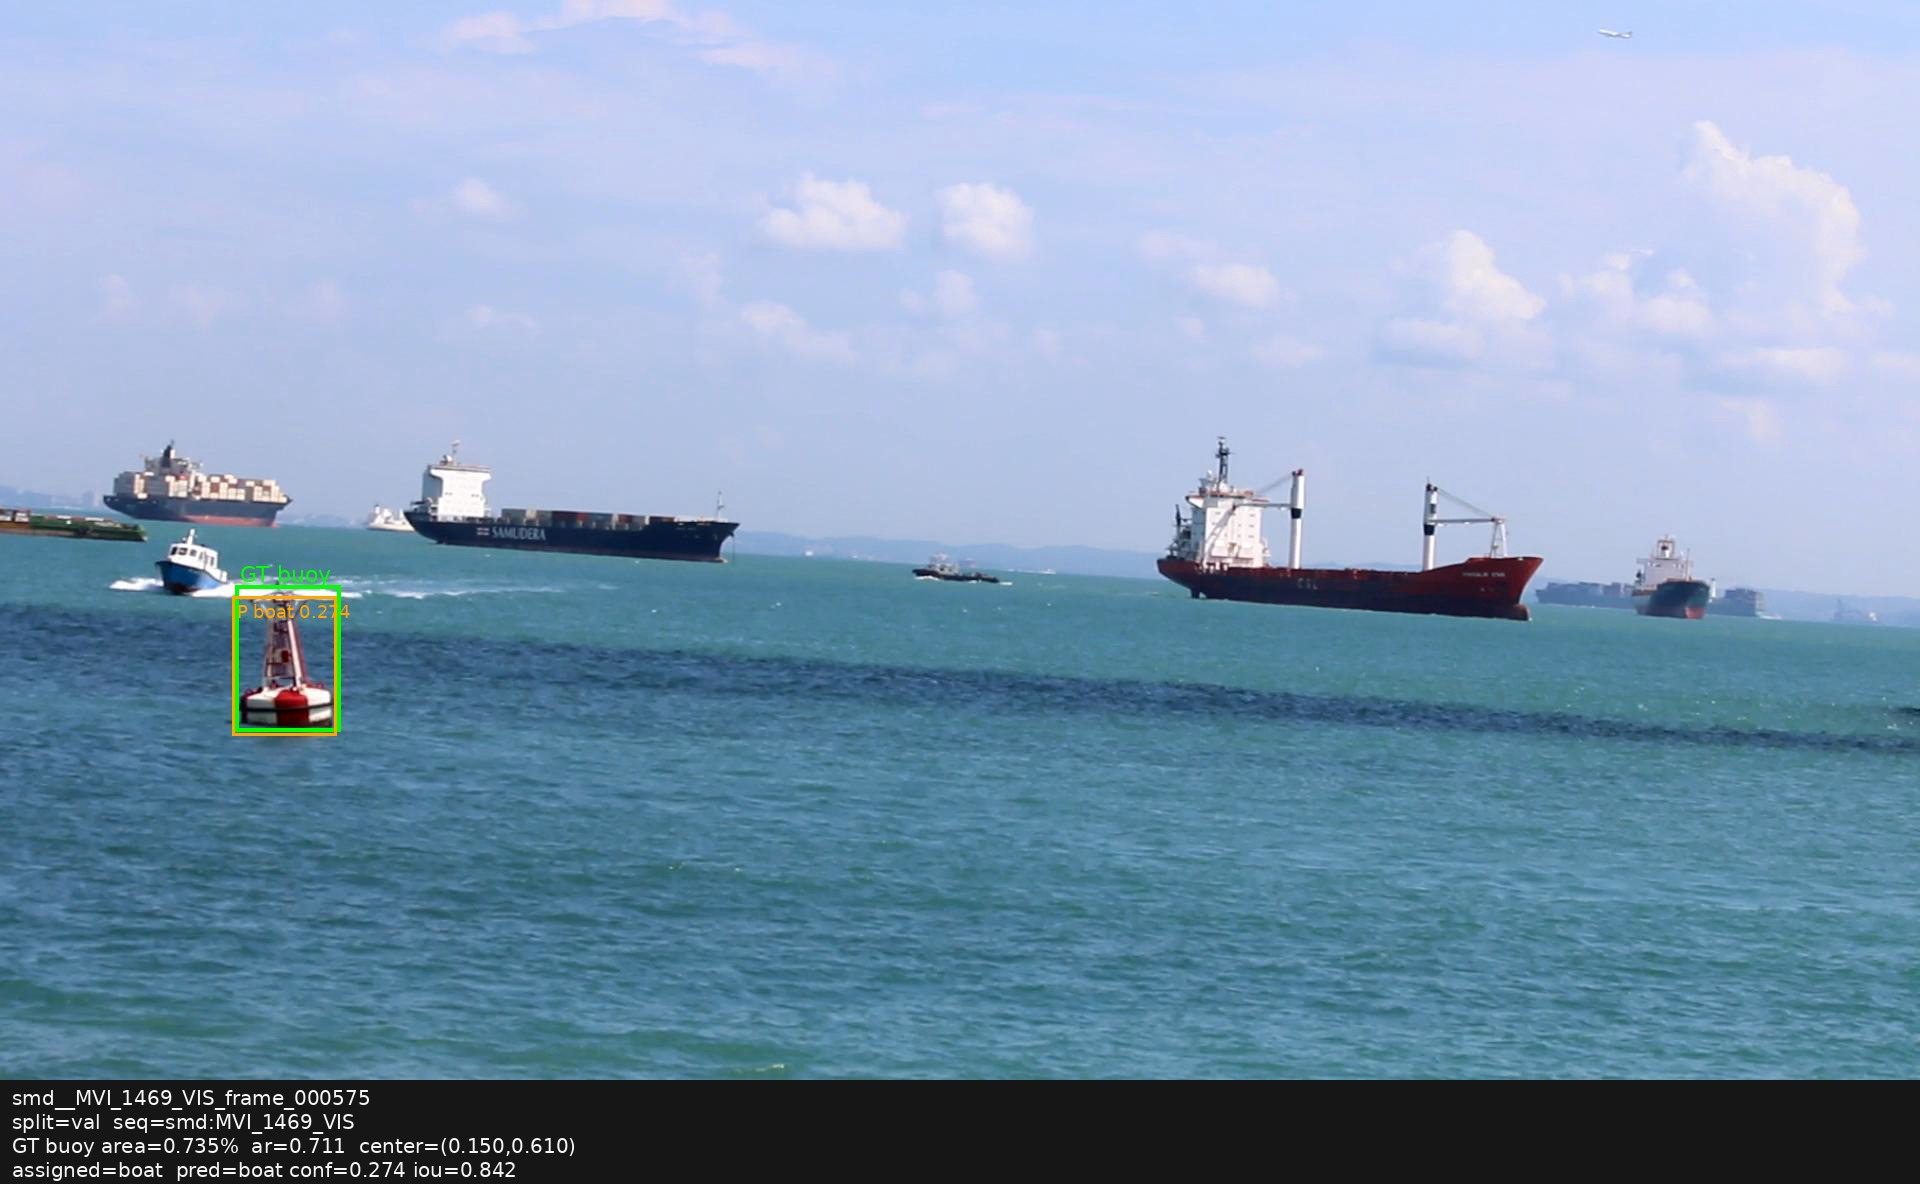

### GT buoy predicted as low-confidence buoy
`outputs/error_analysis/boat_vs_buoy/02_val_buoy_lowconf/029_smd__MVI_1469_VIS_frame_000223_cx288_cy656.jpg`

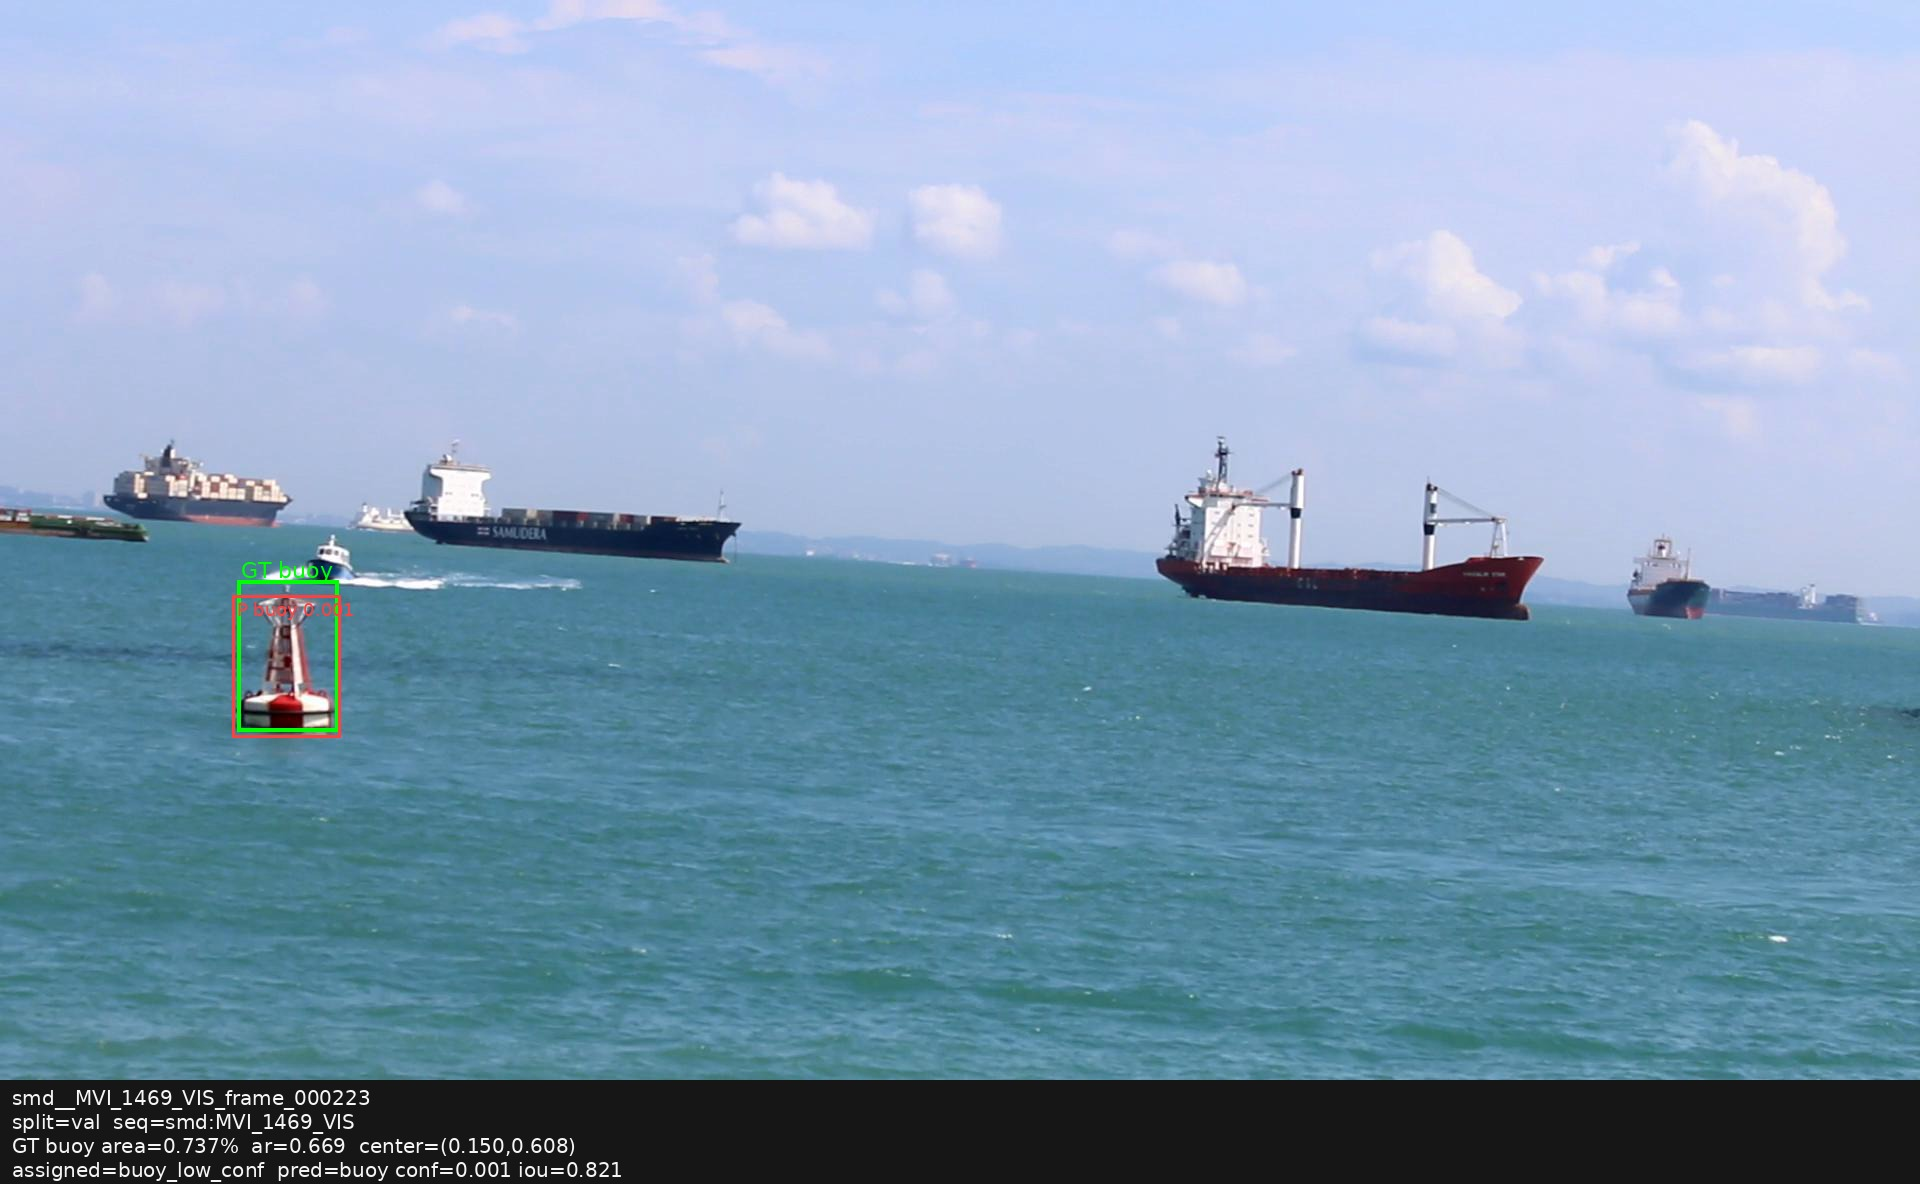

### GT buoy missed as background
`outputs/error_analysis/boat_vs_buoy/03_val_buoy_background/021_smd__MVI_1469_VIS_frame_000010_cx278_cy657.jpg`

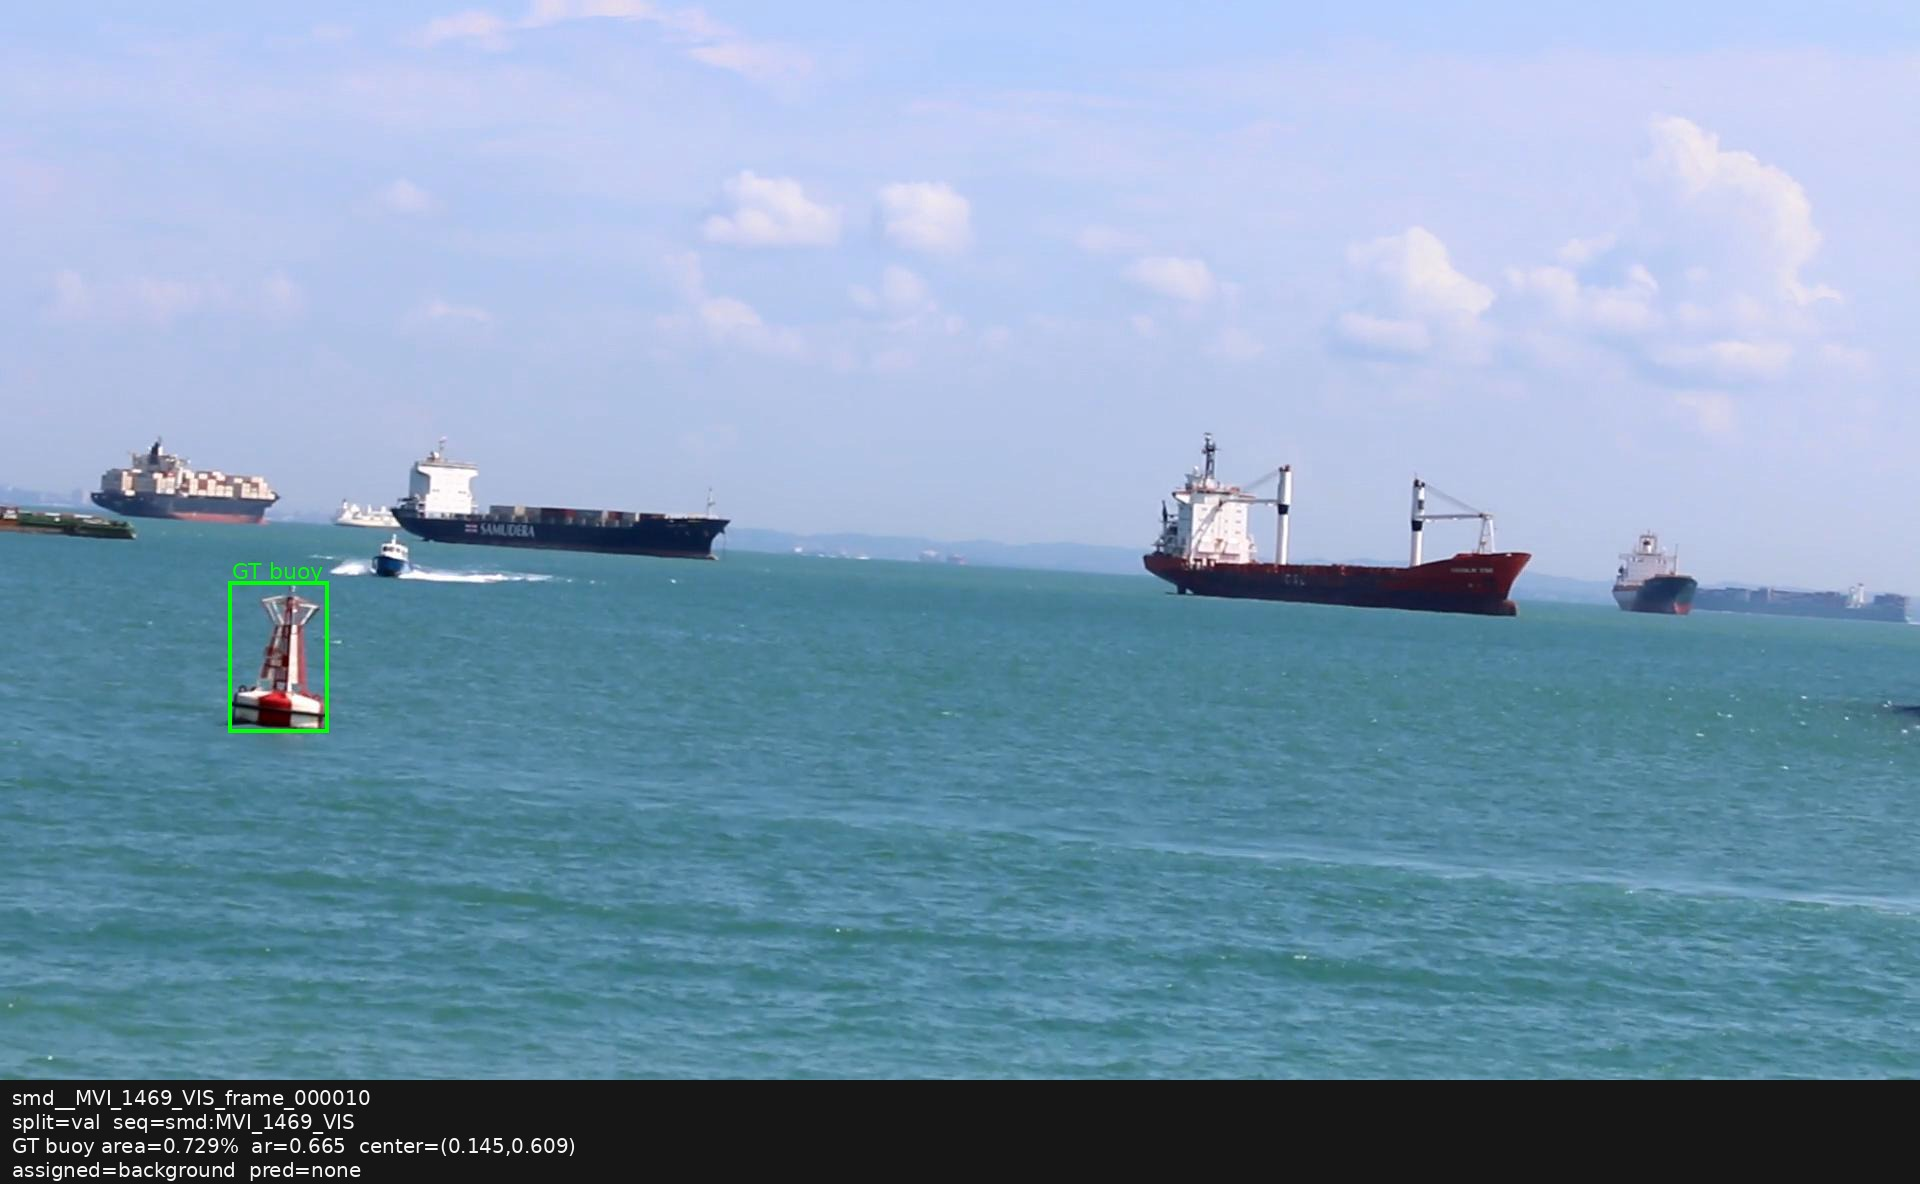

### Train buoy reference
`outputs/error_analysis/boat_vs_buoy/04_train_buoy_reference/003_smd__MVI_1486_VIS_frame_000151_cx1124_cy698.jpg`

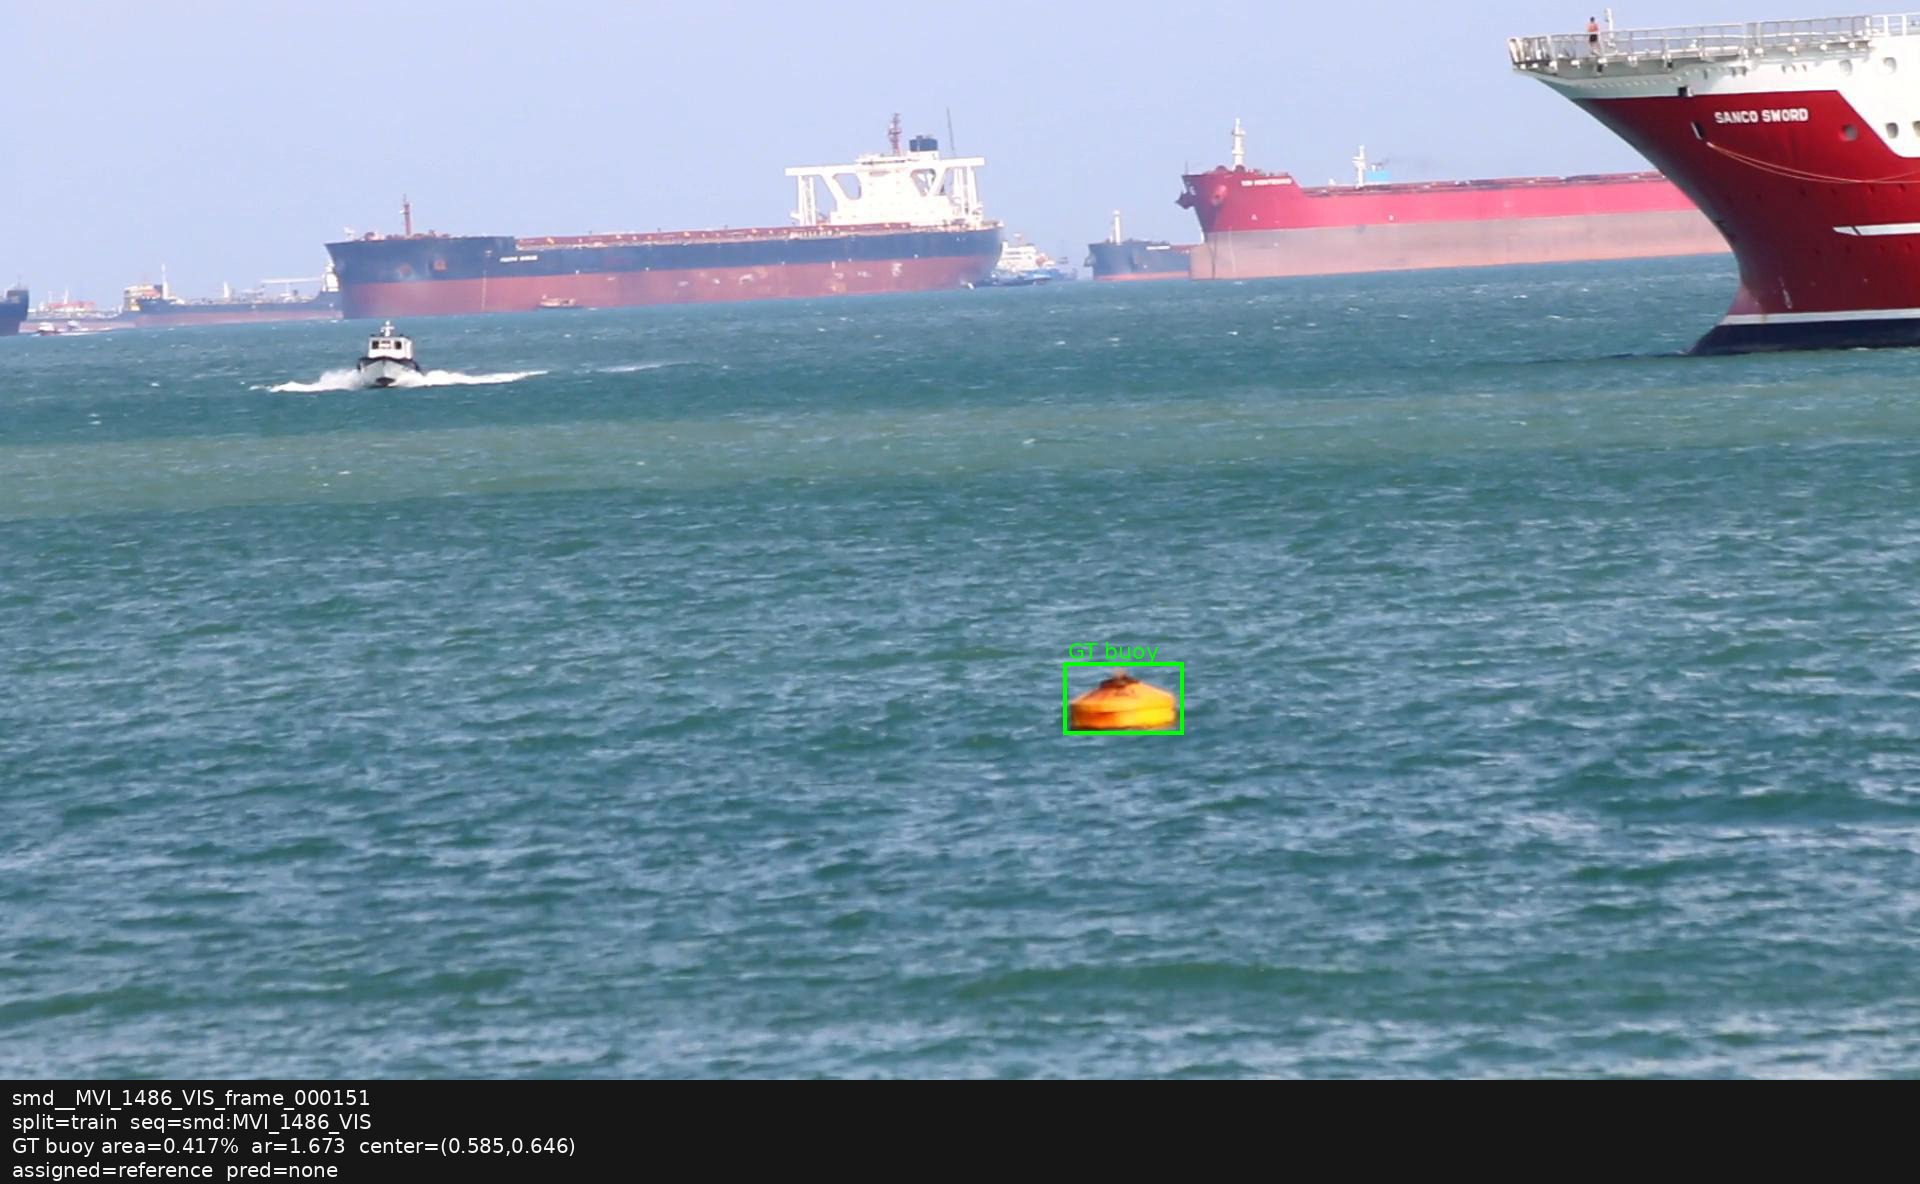

### Train boat visually close to buoy regime
`outputs/error_analysis/boat_vs_buoy/05_train_boat_buoy_like/012_smd__MVI_0790_VIS_OB_frame_000134_cx862_cy663.jpg`

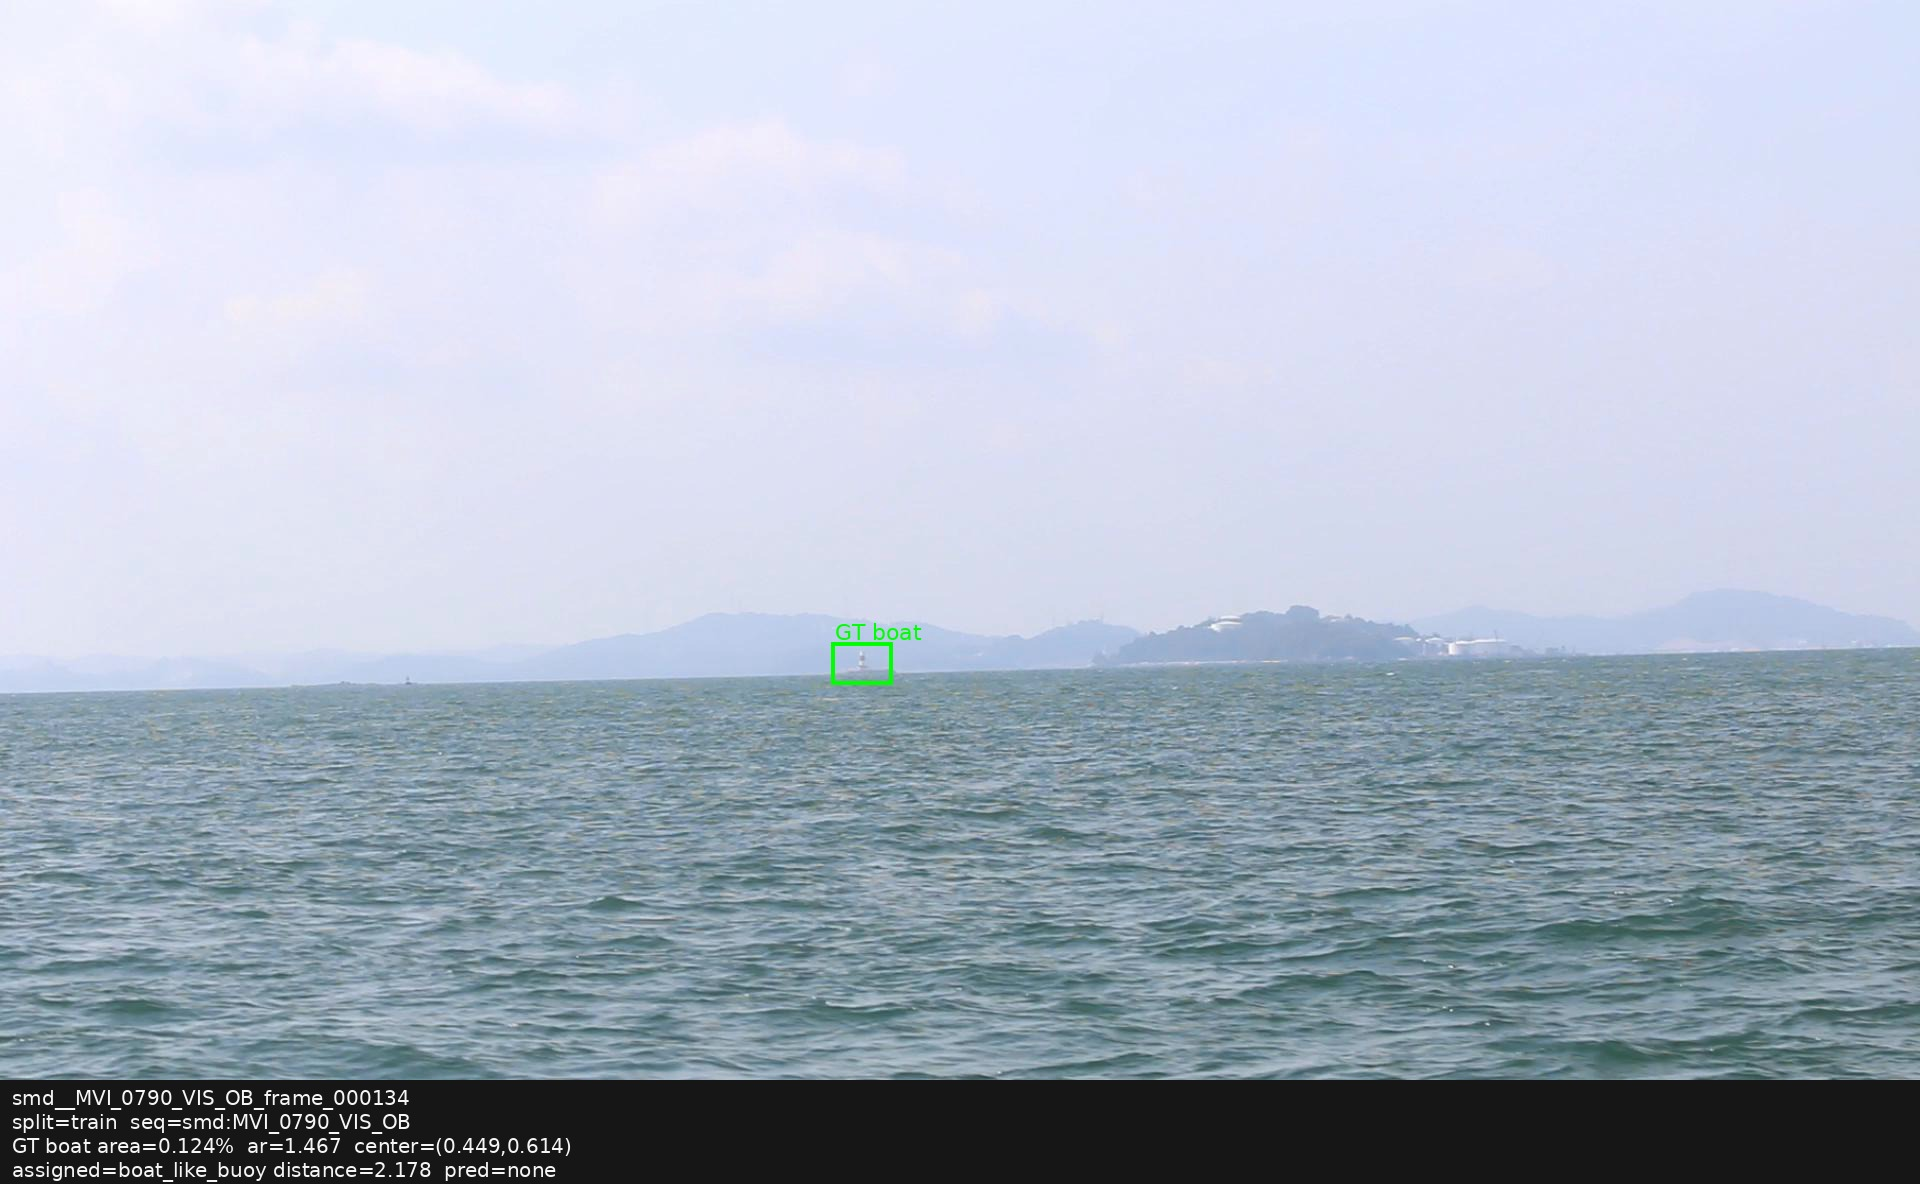

In [6]:
boat_vs_buoy_panel = [
    ("GT buoy predicted as boat", 'outputs/error_analysis/boat_vs_buoy/01_val_buoy_as_boat/046_smd__MVI_1469_VIS_frame_000575_cx288_cy659.jpg'),
    ("GT buoy predicted as low-confidence buoy", 'outputs/error_analysis/boat_vs_buoy/02_val_buoy_lowconf/029_smd__MVI_1469_VIS_frame_000223_cx288_cy656.jpg'),
    ("GT buoy missed as background", 'outputs/error_analysis/boat_vs_buoy/03_val_buoy_background/021_smd__MVI_1469_VIS_frame_000010_cx278_cy657.jpg'),
    ("Train buoy reference", 'outputs/error_analysis/boat_vs_buoy/04_train_buoy_reference/003_smd__MVI_1486_VIS_frame_000151_cx1124_cy698.jpg'),
    ("Train boat visually close to buoy regime", 'outputs/error_analysis/boat_vs_buoy/05_train_boat_buoy_like/012_smd__MVI_0790_VIS_OB_frame_000134_cx862_cy663.jpg'),
]
for title, image_path in boat_vs_buoy_panel:
    display(Markdown(f"### {title}\n`{image_path}`"))
    show_image(image_path, width=760)

<div class="callout-observation"><strong>Figure Interpretation.</strong> The first three examples show the main failure modes: semantic confusion, low-confidence semantic recognition, and outright misses. The last two examples help explain why: the train buoy regime is narrow, and some train boat examples live in a visually similar small-object regime.</div>

<div class="muted">What the reader should learn from these images: the current evidence supports a combined explanation based on class scarcity, pseudo-sequence scarcity, subtype shift inside <code>buoy</code>, and semantic overlap between <code>boat</code> and <code>buoy</code>.</div>


<div class="report-section"><h2>10. Challenges Encountered</h2></div>

- <strong>Challenge 1 - Class imbalance.</strong> At the aggregate class-count level, imbalance is not catastrophic. However, class balance becomes misleading once the data is grouped by pseudo-sequence and visual subtype.
- <strong>Challenge 2 - Boat vs buoy visual similarity.</strong> This is currently the most important semantic challenge. Many buoy instances are visible but classified as boat, suggesting that the learned class boundary is not stable enough.
- <strong>Challenge 3 - Small object detection.</strong> Many buoy are small, distant, or low-profile floating objects. Even when the model sees them, confidence can be low and semantic separation can be weak.
- <strong>Challenge 4 - Environmental variability.</strong> Maritime scenes are strongly affected by reflections, waves, wake patterns, illumination changes, visibility changes, and clutter. These factors amplify small-object difficulty and increase ambiguity near the waterline.
- <strong>Challenge 5 - Dataset limitations.</strong> The current dataset has only five buoy-bearing pseudo-sequences, many sequences are nearly monoclasse, and annotation quality likely needs targeted review for <code>boat</code> vs <code>buoy</code>.

<div class="callout-warning"><strong>Warning.</strong> The challenge profile is consistent: the project is constrained more by data coverage and semantic boundary quality than by the absence of a detector architecture.</div>


<div class="report-section"><h2>11. Lessons Learned</h2></div>

- ✅ Dataset quality matters more than model complexity.
- ✅ Leakage-aware evaluation is essential.
- ✅ Error analysis is more informative than a single aggregate metric.
- ✅ Small objects remain the most difficult category.
- ✅ Maritime environments introduce unique challenges that generic object detection summaries can hide.
- ✅ A larger model is not the first solution when the failure is semantic or dataset-driven.

<div class="callout-insight"><strong>Key Insight.</strong> Reliable evaluation is more valuable than inflated scores, because it turns future decisions into evidence-driven decisions.</div>


<div class="report-section"><h2>12. Current Assessment</h2></div>

This section is intentionally critical and not overly optimistic.

### Project Status Dashboard

| Component | Status |
| --- | --- |
| Dataset Pipeline | 🟢 Completed |
| Data Quality Audit | 🟢 Completed |
| Baseline Detector | 🟢 Completed |
| Quantitative Evaluation | 🟢 Completed |
| Error Analysis | 🟢 Completed |
| Boat Recognition | 🟡 Moderate |
| Buoy Recognition | 🟡 Needs Improvement |
| Object Tracking | 🔴 Not Started |
| Thermal Integration | 🔴 Not Started |
| Raspberry Pi Deployment | 🔴 Not Started |

<strong>Interpretation.</strong>  
This dashboard shows that the project is already mature from a research-process perspective: the pipeline, audit, baseline, and evaluation stack are in place. What remains immature is not the existence of a method, but the robustness of specific perception capabilities, especially <code>buoy</code> recognition.

### What works well
- the taxonomy and dataset policy are clear
- the engineering pipeline is reproducible
- <code>ship</code> works well
- the project now has a trustworthy evaluation methodology

### What partially works
- <code>boat</code> has become usable again on <code>balanced-v2</code>
- the RGB branch is strong enough to support meaningful iteration and future deployment experiments

### What does not yet work
- <code>buoy</code> does not yet generalize robustly
- current splits still expose major buoy fragility
- the project cannot yet claim stable multi-class maritime awareness on the RGB branch alone

<div class="callout-observation"><strong>Important Observation.</strong> The transition from assessment to future work is straightforward: the next actions should reinforce what is already methodologically strong while directly addressing the specific buoy and small-object weaknesses identified by the analysis.</div>


<div class="report-section"><h2>13. Future Work</h2></div>

### Roadmap progression
- ✅ Phase 1 - Dataset preparation
- ✅ Phase 2 - Baseline development
- ✅ Phase 3 - Evaluation and audit
- 🟡 Phase 4 - Improvement of buoy recognition and small-object handling
- 🔴 Phase 5 - Object tracking
- 🔴 Phase 6 - Multimodal perception
- 🔴 Phase 7 - Raspberry Pi deployment

### Phase 4 - Dataset refinement and buoy improvement
- relabel verification
- class balancing at the pseudo-sequence level
- targeted augmentation only after dataset issues are better controlled

### Phase 5 - Small object optimization
- higher resolution training
- image tiling
- architecture changes only after the data bottleneck is better characterized

### Phase 6 - Object tracking
- DeepSORT
- ByteTrack

### Phase 7 - Multimodal perception and deployment
- RGB camera
- thermal camera
- stereo vision
- model optimization
- edge inference
- real-time testing

<div class="callout-future"><strong>Future Direction.</strong> The roadmap is evidence-based: the next priorities come directly from the observed buoy bottlenecks, semantic ambiguity, and small-object limits documented above.</div>


<div class="report-section"><h2>14. Alignment with EASY Project Objectives</h2></div>

The work completed so far contributes directly to the broader EASY vision, even though the current detector is only the first operational component of that system.

1. <strong>Maritime environmental awareness.</strong> The project has already established a perception baseline tailored to realistic sea scenes rather than generic object-detection benchmarks.
2. <strong>Object recognition.</strong> A trustworthy RGB detector for <code>boat</code>, <code>ship</code>, and <code>buoy</code> is now in place as a measurable baseline.
3. <strong>Modular perception systems.</strong> The repository has been structured as a modular pipeline: staging, conversion, validation, split construction, training, and audit are separated clearly.
4. <strong>Future multimodal sensing.</strong> By keeping MassMIND as a thermal companion rather than forcing an early merge, the project preserves a realistic path toward multimodal maritime sensing.
5. <strong>Future RGB + Thermal integration.</strong> The current RGB branch identifies what is already possible with standard visible imagery and where it fails.
6. <strong>Future embedded deployment.</strong> The use of a lightweight YOLO baseline keeps the work aligned with edge-oriented deployment goals, including Raspberry Pi experimentation.

<div class="callout-insight"><strong>Key Insight.</strong> The current detector should be viewed as the first foundational perception component of a larger maritime awareness system, not as an isolated benchmark exercise.</div>


<div class="report-section"><h2>15. Final Conclusions</h2></div>

The current EASY phase has produced more than a set of detector metrics. It has delivered a <strong>trustworthy research baseline</strong>, a reproducible data pipeline, and a clear empirical understanding of where the maritime perception problem is genuinely hard.

The most important achievements are methodological as well as technical:
- the taxonomy has been frozen and documented
- the dataset pipeline has been implemented end-to-end
- multiple split strategies have been audited
- leakage has been detected and corrected
- pseudo-sequence-aware evaluation has been established as the project standard
- <code>boat</code>, <code>ship</code>, and especially <code>buoy</code> have been analyzed quantitatively and qualitatively

This rigor matters because it makes the current baseline scientifically credible. The original optimistic results could have led to misleading conclusions, but the leakage audit transformed them into an upper bound and replaced them with a more defensible evaluation regime. As a result, the project can now distinguish between apparent performance and real generalization.

The central scientific finding is also clear: <code>buoy</code> is the dominant bottleneck, and it fails for understandable reasons. The evidence points to a combination of pseudo-sequence scarcity, limited subtype diversity, small-object difficulty, and semantic overlap with <code>boat</code>. This means the project is no longer guessing about the source of the problem; it has identified it with concrete supporting evidence.

At the same time, the current state is encouraging. <code>ship</code> is stable, <code>boat</code> is usable, the baseline is lightweight and deployment-aware, and the full workflow from dataset preparation to error analysis is operational. The roadmap is therefore no longer speculative. It is evidence-driven and naturally prioritizes buoy data quality, buoy coverage, semantic cleanup, and small-object-focused refinement before more aggressive model scaling.

<div class="callout-future"><strong>Final Takeaway.</strong> The project has successfully established a solid baseline and identified the most critical bottlenecks, providing a clear path toward a robust maritime awareness system.</div>
